In [1]:
# Cell 1 - Load preprocessed time-series data

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

input_path = "../dataset/CMI_timeseries_preprocessed_outputs.pkl"

with open(input_path, "rb") as f:
    data = pickle.load(f)

CMI_timeseries_preprocessed = data["CMI_timeseries_preprocessed"]
CMI_timeseries_global_scaled = data["CMI_timeseries_global_scaled"]
CMI_timeseries_subject_scaled = data["CMI_timeseries_subject_scaled"]

signal_cols = data["signal_cols"]
id_col = data["id_col"]
target_col = data["target_col"]

print("Number of preprocessed time series:", len(CMI_timeseries_preprocessed))
print("Available signal columns:", signal_cols)
print("ID column:", id_col)
print("Target column:", target_col)

print("\nExample time series shape:")
print(CMI_timeseries_preprocessed[0].shape)

print("\nExample columns:")
print(CMI_timeseries_preprocessed[0].columns.tolist())

Number of preprocessed time series: 4310
Available signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
ID column: id
Target column: sii_binary

Example time series shape:
(200, 13)

Example columns:
['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']


# Motif and Discord Discovery

The goal of this notebook is to identify repeated and anomalous temporal patterns in the time-series dataset.

Following the course material, we use the Matrix Profile as the main method for motif and discord discovery. Given a time series and a subsequence length `m`, the Matrix Profile stores, for each subsequence, the distance to its nearest neighbor. Low Matrix Profile values indicate repeated subsequences, called motifs, while high Matrix Profile values indicate unique or anomalous subsequences, called discords.

We focus mainly on the `enmo` signal because it is directly interpretable as movement/activity intensity. The analysis is first illustrated on one subject and then extended to a stratified sample of subjects from both classes.

Selected subject id: 2265
Target class: 0
Signal: enmo
Time series length: 200


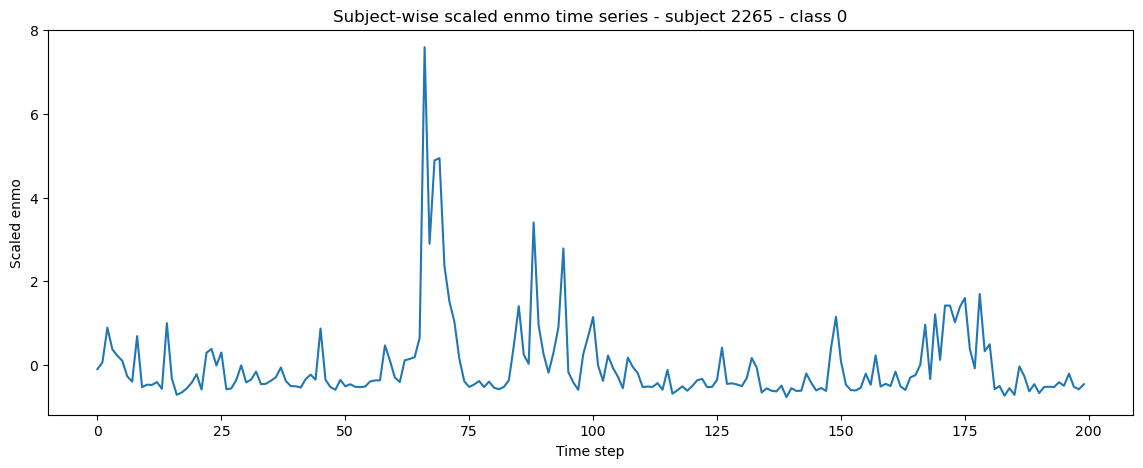

In [2]:
# Cell 2 - Select and visualize one univariate time series

signal_to_analyze = "enmo"

# We start from one subject for interpretability
example_idx = 0

# Use subject-wise scaled data for motif/discord discovery,
# because motifs and discords are shape-based subsequence patterns
example_ts_df = CMI_timeseries_subject_scaled[example_idx]

ts = example_ts_df[signal_to_analyze].to_numpy()

subject_id = example_ts_df[id_col].iloc[0]
target_value = example_ts_df[target_col].iloc[0]

print("Selected subject id:", subject_id)
print("Target class:", target_value)
print("Signal:", signal_to_analyze)
print("Time series length:", len(ts))

plt.figure(figsize=(14, 5))
plt.plot(ts)
plt.title(f"Subject-wise scaled {signal_to_analyze} time series - subject {subject_id} - class {target_value}")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.show()

### Selection of a univariate time series for Matrix Profile analysis

We selected the `enmo` signal for one subject as the first example for Matrix Profile analysis. The `enmo` variable is used because it is directly interpretable as a proxy for physical activity intensity.

The time series is subject-wise standardized, meaning that values are expressed relative to the subject's own average and standard deviation. This is useful for motif and discord discovery because these methods focus on temporal shapes rather than absolute signal magnitude.

The selected time series shows several activity peaks, especially around the middle of the sequence. These peaks may correspond to meaningful activity bursts. Matrix Profile analysis will allow us to identify repeated subsequences, called motifs, and unusual subsequences, called discords.

In [3]:
# Cell 3 - Install/import STUMPY for Matrix Profile computation

import sys

try:
    import stumpy
    print("stumpy is already installed.")
except ModuleNotFoundError:
    print("stumpy not found. Installing...")
    !{sys.executable} -m pip install stumpy
    import stumpy
    print("stumpy installed and imported successfully.")

stumpy is already installed.


In [4]:
# Cell 4 - Compute Matrix Profile for the selected univariate time series

m = 12  # subsequence length: 12 time steps = 6 hours

# STUMPY requires float64 input
ts = ts.astype(np.float64)

matrix_profile = stumpy.stump(ts, m=m)

# STUMPY returns several columns.
# Column 0 = Matrix Profile values
# Column 1 = Matrix Profile nearest-neighbor indices
mp_values = matrix_profile[:, 0].astype(float)
mp_indices = matrix_profile[:, 1].astype(int)

print("Time series length:", len(ts))
print("Subsequence length m:", m)
print("Number of subsequences:", len(ts) - m + 1)
print("Matrix Profile length:", len(mp_values))

print("\nFirst 10 Matrix Profile values:")
print(mp_values[:10])

print("\nFirst 10 Matrix Profile nearest-neighbor indices:")
print(mp_indices[:10])

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Time series length: 200
Subsequence length m: 12
Number of subsequences: 189
Matrix Profile length: 189

First 10 Matrix Profile values:
[2.00208917 2.04895886 1.97041694 2.41532167 2.01004211 1.61831623
 1.60038615 1.57758257 1.51415592 1.14204329]

First 10 Matrix Profile nearest-neighbor indices:
[ 86  87 172 121  84  85  86  87 109  40]


### Matrix Profile computation

We computed the Matrix Profile for the selected univariate `enmo` time series using a subsequence length `m = 12`. Since each time step corresponds to 30 minutes, this window length represents a 6-hour temporal pattern.

The original time series has length 200. Therefore, the number of possible subsequences of length 12 is:

`200 - 12 + 1 = 189`

Accordingly, the Matrix Profile contains 189 values, one for each possible subsequence.

Each Matrix Profile value represents the distance between a subsequence and its nearest neighbor elsewhere in the same time series. Low Matrix Profile values indicate subsequences that are similar to another subsequence and are therefore candidate motifs. High Matrix Profile values indicate subsequences that are very different from all others and are therefore candidate discords or anomalies.

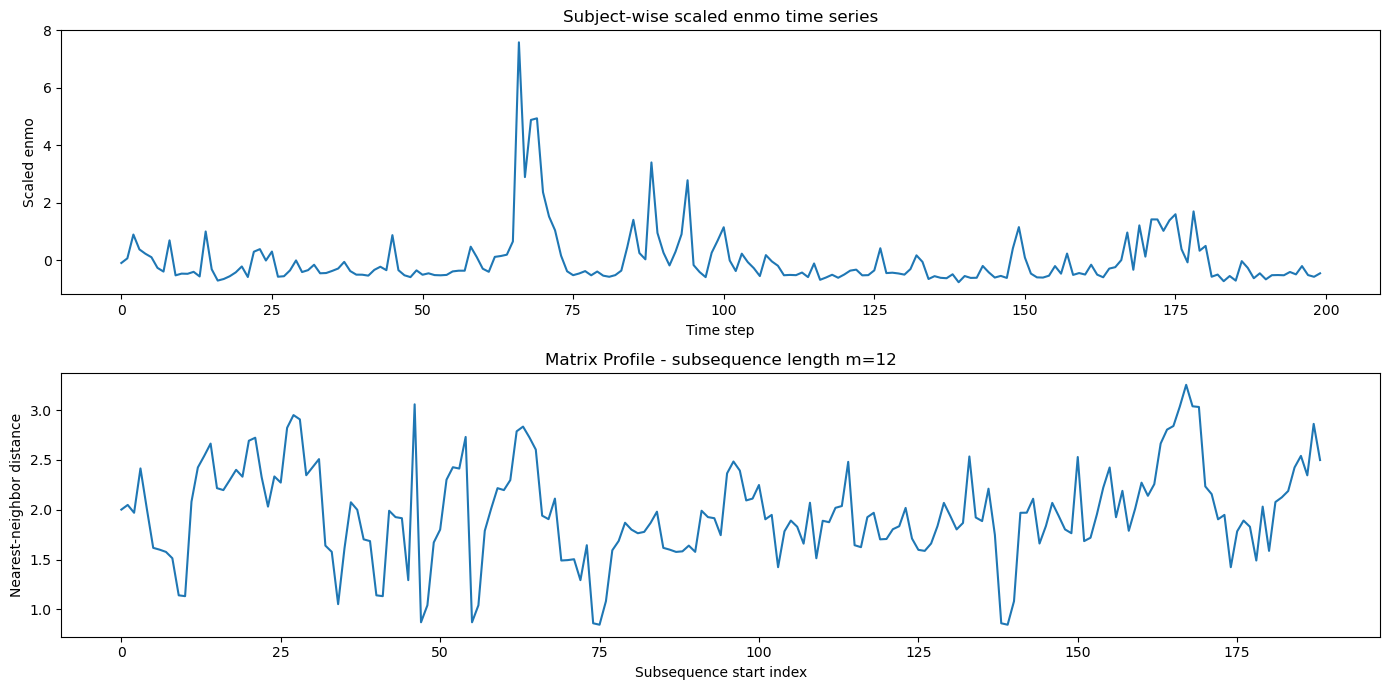

In [5]:
# Cell 5 - Plot the time series and its Matrix Profile

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(ts)
axes[0].set_title(f"Subject-wise scaled {signal_to_analyze} time series")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel(f"Scaled {signal_to_analyze}")

axes[1].plot(mp_values)
axes[1].set_title(f"Matrix Profile - subsequence length m={m}")
axes[1].set_xlabel("Subsequence start index")
axes[1].set_ylabel("Nearest-neighbor distance")

plt.tight_layout()
plt.show()


### Matrix Profile visualization

The upper plot shows the subject-wise standardized `enmo` time series for the selected subject, while the lower plot shows the corresponding Matrix Profile computed with subsequence length `m = 12`.

Since each time step represents a 30-minute interval, `m = 12` corresponds to a 6-hour subsequence. Therefore, each Matrix Profile value measures how similar a 6-hour activity pattern is to its nearest neighbor elsewhere in the same time series.

Low Matrix Profile values indicate subsequences that have a close match in another part of the time series. These regions are candidate motifs, i.e. repeated temporal patterns. High Matrix Profile values indicate subsequences that are far from their nearest neighbor and are therefore candidate discords or anomalous patterns.

In this example, the Matrix Profile shows several local minima, suggesting the presence of repeated activity patterns. It also contains some high-value regions, which may correspond to unusual subsequences.

Top motif subsequence start index: 75
Nearest-neighbor subsequence start index: 139
Matrix Profile distance: 0.8469898485237009


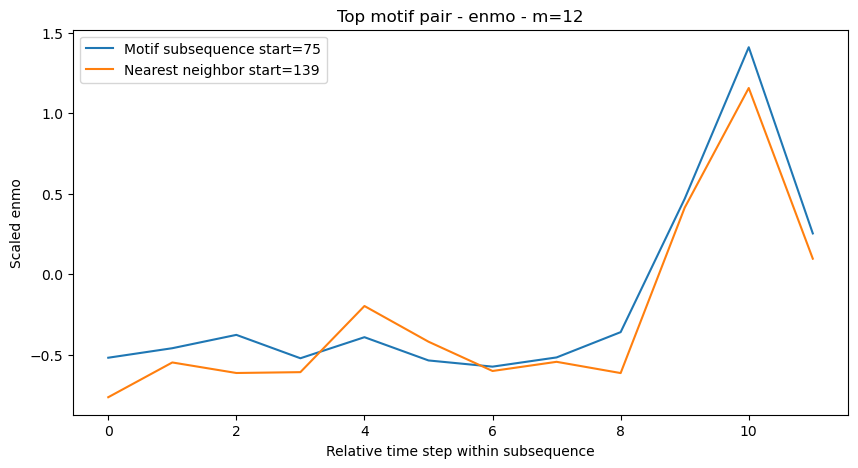

In [6]:
# Cell 6 - Extract the top motif pair from the Matrix Profile

motif_idx = np.argmin(mp_values)
nearest_neighbor_idx = mp_indices[motif_idx]

motif_distance = mp_values[motif_idx]

print("Top motif subsequence start index:", motif_idx)
print("Nearest-neighbor subsequence start index:", nearest_neighbor_idx)
print("Matrix Profile distance:", motif_distance)

motif_subseq = ts[motif_idx : motif_idx + m]
neighbor_subseq = ts[nearest_neighbor_idx : nearest_neighbor_idx + m]

plt.figure(figsize=(10, 5))
plt.plot(motif_subseq, label=f"Motif subsequence start={motif_idx}")
plt.plot(neighbor_subseq, label=f"Nearest neighbor start={nearest_neighbor_idx}")
plt.title(f"Top motif pair - {signal_to_analyze} - m={m}")
plt.xlabel("Relative time step within subsequence")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

### Top motif pair

The top motif pair was identified using the minimum value of the Matrix Profile. The motif subsequence starts at time step `75`, while its nearest-neighbor subsequence starts at time step `139`.

The Matrix Profile distance between the two subsequences is approximately `0.847`. This value represents the distance between the two 6-hour activity patterns after subject-wise standardization.

Visually, the two subsequences have a similar temporal shape: both remain relatively low for most of the window and then show a sharp increase near the end. Therefore, this pair can be interpreted as a repeated local activity pattern within the same subject.

A motif does not require the subsequences to be exactly identical. Rather, it identifies subsequences that are highly similar compared with the other subsequences in the same time series.

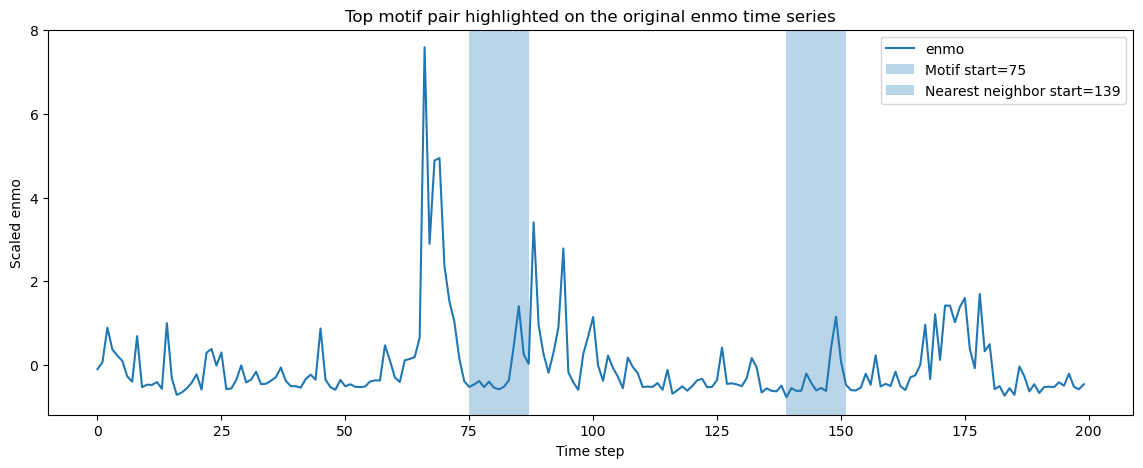

In [7]:
# Cell 7 - Visualize the top motif pair on the original time series

plt.figure(figsize=(14, 5))

plt.plot(ts, label=signal_to_analyze)

plt.axvspan(
    motif_idx,
    motif_idx + m,
    alpha=0.3,
    label=f"Motif start={motif_idx}"
)

plt.axvspan(
    nearest_neighbor_idx,
    nearest_neighbor_idx + m,
    alpha=0.3,
    label=f"Nearest neighbor start={nearest_neighbor_idx}"
)

plt.title(f"Top motif pair highlighted on the original {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

### Motif pair localization in the original time series

We highlighted the top motif pair directly on the original standardized `enmo` time series.

The first motif subsequence starts at time step `75` and covers the interval from `75` to `87`. Its nearest-neighbor subsequence starts at time step `139` and covers the interval from `139` to `151`.

Both subsequences correspond to relatively low-activity intervals followed by a local increase in `enmo`. This explains why they are identified as the most similar 6-hour activity patterns in the selected subject's time series.

This visualization is important because it connects the Matrix Profile result back to the original temporal signal. The motif is not just a pair of indices: it represents a repeated temporal behavior within the subject's activity profile.

Top discord subsequence start index: 167
Matrix Profile distance: 3.2541963529482785


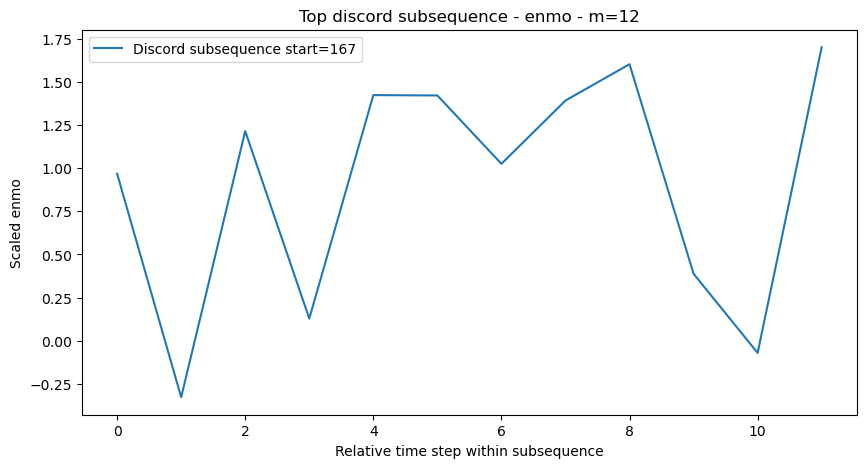

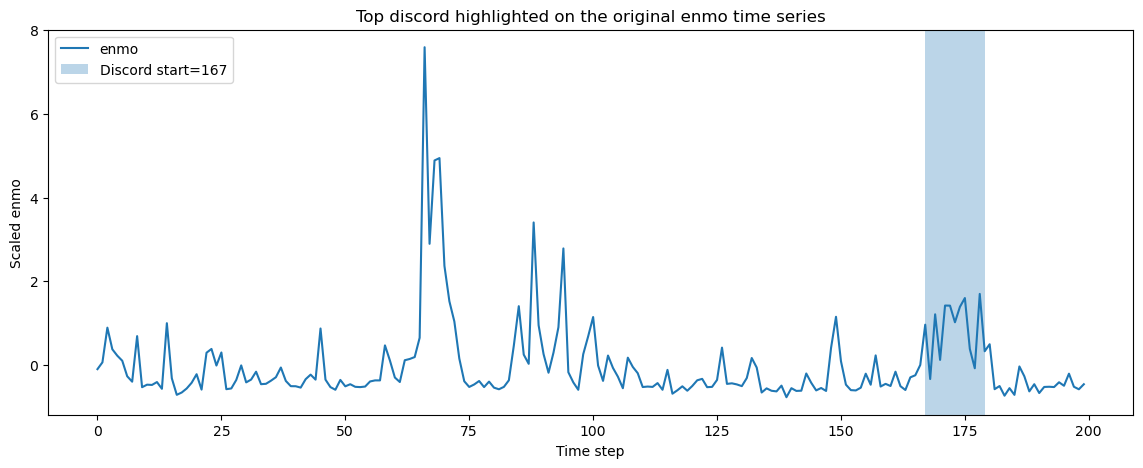

In [8]:
# Cell 8 - Extract and visualize the top discord

discord_idx = np.argmax(mp_values)
discord_distance = mp_values[discord_idx]

print("Top discord subsequence start index:", discord_idx)
print("Matrix Profile distance:", discord_distance)

discord_subseq = ts[discord_idx : discord_idx + m]

plt.figure(figsize=(10, 5))
plt.plot(discord_subseq, label=f"Discord subsequence start={discord_idx}")
plt.title(f"Top discord subsequence - {signal_to_analyze} - m={m}")
plt.xlabel("Relative time step within subsequence")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)
plt.axvspan(
    discord_idx,
    discord_idx + m,
    alpha=0.3,
    label=f"Discord start={discord_idx}"
)
plt.title(f"Top discord highlighted on the original {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend()
plt.show()

### Top discord discovery

We identified the top discord by selecting the subsequence with the highest Matrix Profile value. The top discord starts at time step `167`, and its Matrix Profile distance is approximately `3.254`.

This means that the 6-hour subsequence starting at time step `167` is the most unusual subsequence in the selected `enmo` time series. In other words, even its nearest neighbor is relatively far away, indicating that this pattern is not repeated elsewhere in the same subject's activity profile.

The highlighted discord corresponds to a region with several consecutive positive activity values and a fluctuating temporal shape. Although the time series contains larger peaks earlier, the discord is selected because its overall subsequence shape is the most unique according to the Matrix Profile.

This illustrates the difference between a simple point anomaly and a time-series discord. A discord is not necessarily the single largest value in the series; it is the subsequence whose shape is most dissimilar from all other subsequences.

In [9]:
# Cell 9 - Extract top-k motif pairs with exclusion zone

def apply_exclusion_zone(profile, idx, exclusion_zone):
    """
    Set Matrix Profile values around idx to infinity
    so that overlapping/nearly overlapping subsequences are not selected again.
    """
    start = max(0, idx - exclusion_zone)
    end = min(len(profile), idx + exclusion_zone + 1)
    profile[start:end] = np.inf


k_motifs = 3
exclusion_zone = m  # exclude subsequences starting within m points

mp_motifs = mp_values.copy()
top_motifs = []

for k in range(k_motifs):
    motif_idx = np.argmin(mp_motifs)
    nn_idx = mp_indices[motif_idx]
    motif_distance = mp_values[motif_idx]
    
    top_motifs.append({
        "motif_rank": k + 1,
        "motif_start": motif_idx,
        "nearest_neighbor_start": nn_idx,
        "distance": motif_distance
    })
    
    # Exclude both the motif and its nearest neighbor neighborhoods
    apply_exclusion_zone(mp_motifs, motif_idx, exclusion_zone)
    apply_exclusion_zone(mp_motifs, nn_idx, exclusion_zone)

top_motifs_df = pd.DataFrame(top_motifs)

display(top_motifs_df)

,motif_rank,motif_start,nearest_neighbor_start,distance
0,1,75,139,0.846990
1,2,47,55,0.871409
2,3,34,55,1.053457


### Top-k motif pairs

We extracted the top-3 motif pairs using the Matrix Profile. To avoid repeatedly selecting overlapping subsequences, we applied an exclusion zone around each selected motif and its nearest neighbor.

The strongest motif pair is the one with the smallest Matrix Profile distance. In this case, the top motif starts at time step `75` and its nearest neighbor starts at time step `139`, with a distance of approximately `0.847`.

The second and third motif pairs have slightly larger distances, meaning that they are less similar than the top motif pair but still represent repeated local temporal patterns in the selected `enmo` time series.

Some motif pairs may share a nearest-neighbor subsequence. This can happen because nearest-neighbor relationships in the Matrix Profile are not necessarily symmetric and because we are using a simple manual top-k extraction procedure. Nevertheless, the result is useful for identifying repeated activity patterns and for connecting the implementation to the Matrix Profile theory.

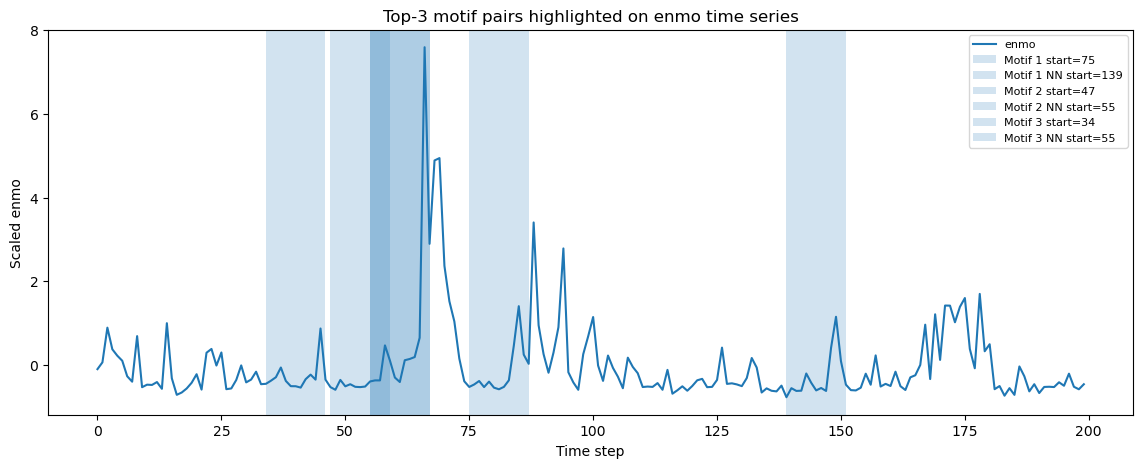

In [10]:
# Cell 10 - Visualize top-k motif pairs on the original time series

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)

for _, row in top_motifs_df.iterrows():
    rank = int(row["motif_rank"])
    start_1 = int(row["motif_start"])
    start_2 = int(row["nearest_neighbor_start"])
    
    plt.axvspan(
        start_1,
        start_1 + m,
        alpha=0.20,
        label=f"Motif {rank} start={start_1}"
    )
    
    plt.axvspan(
        start_2,
        start_2 + m,
        alpha=0.20,
        label=f"Motif {rank} NN start={start_2}"
    )

plt.title(f"Top-{k_motifs} motif pairs highlighted on {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend(loc="upper right", fontsize=8)
plt.show()

### Top-3 motif pairs visualization

We visualized the top-3 motif pairs on the original standardized `enmo` time series. The highlighted regions show where the repeated subsequences occur in the temporal signal.

The detected motifs are mostly located in low-to-moderate activity regions, often close to local transitions or small peaks. This confirms that motif discovery is based on repeated temporal shapes, not simply on the largest signal values.

Some highlighted regions are close to each other or partially overlapping. This is due to the manual top-k extraction procedure and the chosen exclusion zone. The result shows that motif discovery depends on both the subsequence length `m` and the exclusion strategy used to avoid selecting trivial overlapping matches.

Overall, the top-k motifs identify repeated 6-hour activity patterns within the selected subject's `enmo` signal. These repeated patterns may later be compared with shapelets: motifs are unsupervised repeated subsequences, while shapelets are discriminative subsequences selected for classification.

In [11]:
# Cell 11 corrected - Extract top-k discords excluding motif regions

k_discords = 3
exclusion_zone = m

mp_discords = mp_values.copy()

# First, exclude all motif regions and their nearest-neighbor regions
for _, row in top_motifs_df.iterrows():
    motif_start = int(row["motif_start"])
    nn_start = int(row["nearest_neighbor_start"])
    
    apply_exclusion_zone(mp_discords, motif_start, exclusion_zone)
    apply_exclusion_zone(mp_discords, nn_start, exclusion_zone)

top_discords = []

for k in range(k_discords):
    discord_idx = np.argmax(mp_discords)
    discord_distance = mp_values[discord_idx]
    
    top_discords.append({
        "discord_rank": k + 1,
        "discord_start": discord_idx,
        "distance": discord_distance
    })
    
    apply_exclusion_zone(mp_discords, discord_idx, exclusion_zone)

top_discords_df = pd.DataFrame(top_discords)

display(top_discords_df)

,discord_rank,discord_start,distance
0,1,22,2.329490
1,2,10,1.133599
2,3,0,2.002089


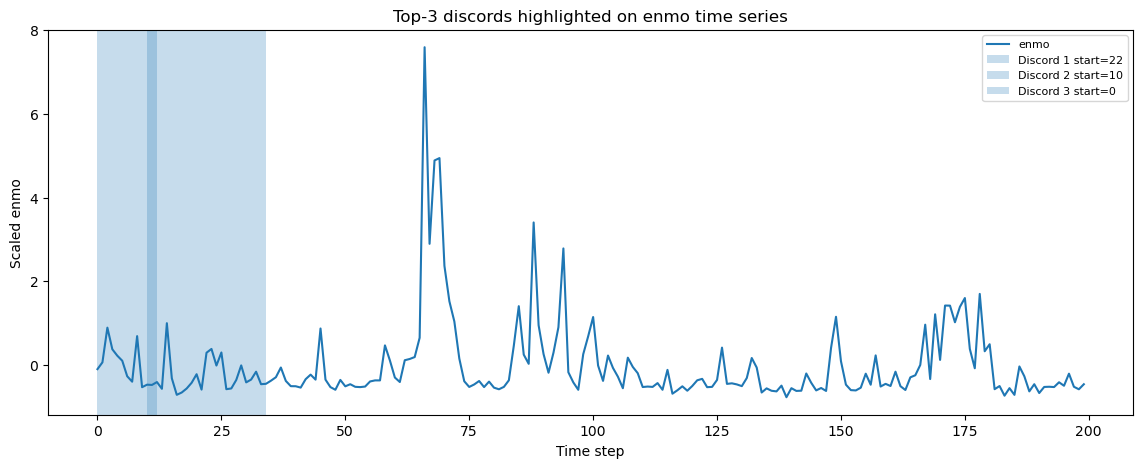

In [12]:
# Cell 12 - Visualize top-k discords on the original time series

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)

for _, row in top_discords_df.iterrows():
    rank = int(row["discord_rank"])
    start = int(row["discord_start"])
    
    plt.axvspan(
        start,
        start + m,
        alpha=0.25,
        label=f"Discord {rank} start={start}"
    )

plt.title(f"Top-{k_discords} discords highlighted on {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend(loc="upper right", fontsize=8)
plt.show()

### Top-3 discords visualization

We visualized the top-3 discords on the original standardized `enmo` time series. The detected discords are concentrated in the later part of the sequence, approximately between time steps `143` and `179`.

This region contains several moderate activity increases and fluctuations. Although the largest individual peak in the time series occurs earlier, around time steps `65–70`, the Matrix Profile identifies the later region as more anomalous because its overall subsequence shape is less similar to all other subsequences.

This highlights an important distinction: a time-series discord is not simply a single extreme value. Instead, it is a subsequence whose temporal pattern is unusual compared with the rest of the series.

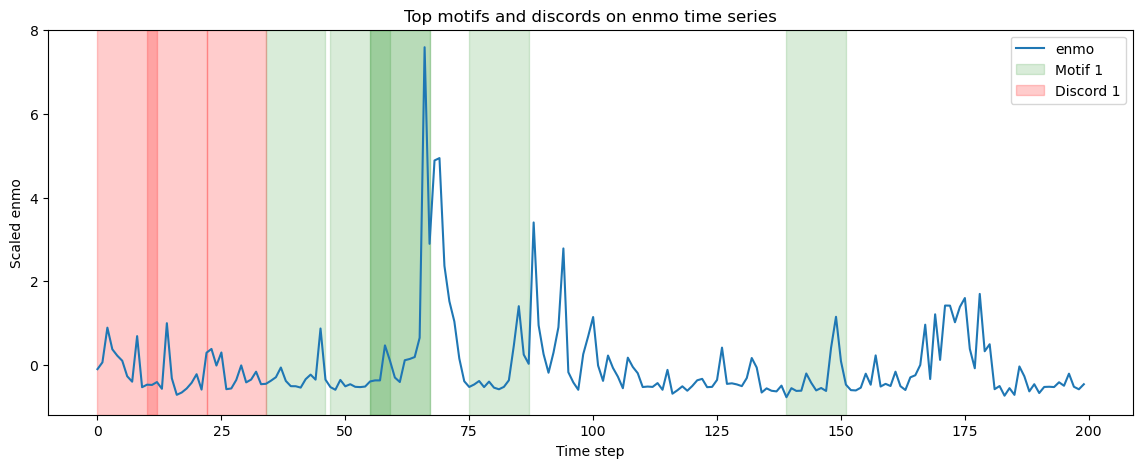

In [13]:
# Cell 13 - Visualize motifs and discords together

plt.figure(figsize=(14, 5))
plt.plot(ts, label=signal_to_analyze)

# Highlight motif regions
for _, row in top_motifs_df.iterrows():
    rank = int(row["motif_rank"])
    start_1 = int(row["motif_start"])
    start_2 = int(row["nearest_neighbor_start"])
    
    plt.axvspan(
        start_1,
        start_1 + m,
        alpha=0.15,
        color="green",
        label=f"Motif {rank}" if rank == 1 else None
    )
    
    plt.axvspan(
        start_2,
        start_2 + m,
        alpha=0.15,
        color="green"
    )

# Highlight discord regions
for _, row in top_discords_df.iterrows():
    rank = int(row["discord_rank"])
    start = int(row["discord_start"])
    
    plt.axvspan(
        start,
        start + m,
        alpha=0.20,
        color="red",
        label=f"Discord {rank}" if rank == 1 else None
    )

plt.title(f"Top motifs and discords on {signal_to_analyze} time series")
plt.xlabel("Time step")
plt.ylabel(f"Scaled {signal_to_analyze}")
plt.legend(loc="upper right")
plt.show()

## Dataset-level motif and discord analysis

After illustrating Matrix Profile analysis on a single subject, we extend the analysis to a stratified sample of subjects from both classes. This is necessary because the task requires analyzing the dataset, not only one individual time series.

For each sampled subject, we compute the Matrix Profile of the subject-wise standardized `enmo` signal using subsequence length `m = 12`, corresponding to a 6-hour pattern. We then extract two summary quantities:

- the minimum Matrix Profile value, representing the strongest motif;
- the maximum Matrix Profile value, representing the strongest discord.

This allows us to compare the strength of repeated patterns and anomalous subsequences across subjects and between the two target classes.

In [14]:
# Dataset-level Matrix Profile analysis on a stratified sample of subjects

from tqdm import tqdm

signal_to_analyze = "enmo"
m = 12

n_per_class = 50
random_state = 42

# Build target information from the subject-wise scaled dataset
subjects_info = []

for i, ts_df in enumerate(CMI_timeseries_subject_scaled):
    subjects_info.append({
        "series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    })

subjects_info_df = pd.DataFrame(subjects_info)

# Stratified sample: same number of subjects from each class
sample_indices = []

for cls in sorted(subjects_info_df["target"].unique()):
    cls_indices = subjects_info_df[subjects_info_df["target"] == cls]["series_index"]
    sampled = cls_indices.sample(n=n_per_class, random_state=random_state).tolist()
    sample_indices.extend(sampled)

mp_dataset_results = []

for idx in tqdm(sample_indices):
    ts_df = CMI_timeseries_subject_scaled[idx]
    ts_signal = ts_df[signal_to_analyze].to_numpy().astype(np.float64)
    
    mp = stumpy.stump(ts_signal, m=m)
    mp_values_i = mp[:, 0].astype(float)
    
    motif_distance = np.min(mp_values_i)
    discord_distance = np.max(mp_values_i)
    motif_start = np.argmin(mp_values_i)
    discord_start = np.argmax(mp_values_i)
    
    mp_dataset_results.append({
        "series_index": idx,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0],
        "motif_distance": motif_distance,
        "discord_distance": discord_distance,
        "motif_start": motif_start,
        "discord_start": discord_start
    })

mp_dataset_results_df = pd.DataFrame(mp_dataset_results)

display(mp_dataset_results_df.head())

print("Summary by class:")
display(
    mp_dataset_results_df
    .groupby("target")[["motif_distance", "discord_distance"]]
    .describe()
)

100%|██████████| 100/100 [00:00<00:00, 632.89it/s]


,series_index,subject_id,target,motif_distance,discord_distance,motif_start,discord_start
0,727,2071,0,0.6484152042768301,3.22774012386263,38,43
1,1795,3542,0,1.0976332380185234,3.34309144765104,145,177
2,3558,130,0,0.6267974218883975,3.383791751310184,105,32
3,3139,2726,0,1.2103481927822928,3.2511340987371904,57,44
4,4305,1246,0,1.1016362858091924,2.9473330385219745,65,33


Summary by class:


motif_distance                                 discord_distance         \
                count unique                 top freq            count unique   
target                                                                          
0                  50     50  0.6484152042768301    1               50     50   
1                  50     50  0.5382007839381391    1               50     50   

                                 
                       top freq  
target                           
0         3.22774012386263    1  
1       3.3217420330312724    1

motif_distance                                                    \
                count      mean       std       min    median       max   
target                                                                    
0                  50  0.901736  0.248288  0.359934  0.888482  1.536172   
1                  50  0.937241  0.251428  0.394890  0.933712  1.554613   

       discord_distance                                                   
                  count      mean      std       min    median       max  
target                                                                    
0                    50  3.192189  0.14942  2.853067  3.190242  3.513064  
1                    50  3.175348  0.14033  2.857444  3.177164  3.548350

<Figure size 800x500 with 0 Axes>

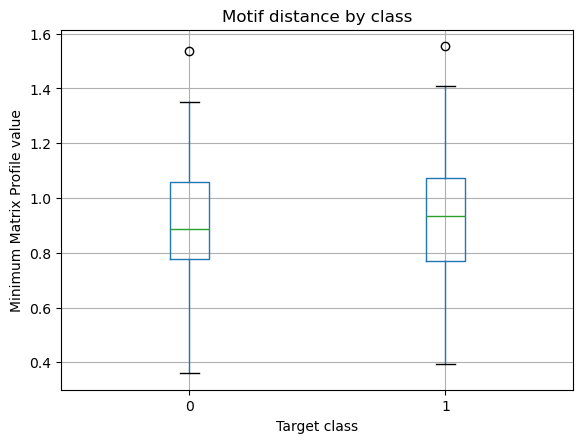

<Figure size 800x500 with 0 Axes>

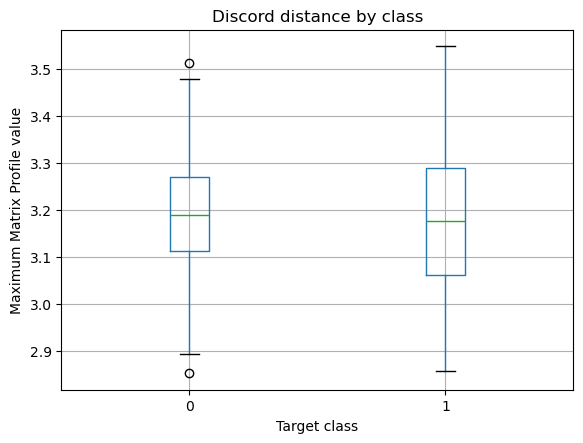

In [15]:
# Clean numerical types and create readable summary by class

mp_dataset_results_df["motif_distance"] = (
    mp_dataset_results_df["motif_distance"]
    .astype(float)
)

mp_dataset_results_df["discord_distance"] = (
    mp_dataset_results_df["discord_distance"]
    .astype(float)
)

summary_by_class = (
    mp_dataset_results_df
    .groupby("target")[["motif_distance", "discord_distance"]]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

display(summary_by_class)

plt.figure(figsize=(8, 5))
mp_dataset_results_df.boxplot(column="motif_distance", by="target")
plt.title("Motif distance by class")
plt.suptitle("")
plt.xlabel("Target class")
plt.ylabel("Minimum Matrix Profile value")
plt.show()

plt.figure(figsize=(8, 5))
mp_dataset_results_df.boxplot(column="discord_distance", by="target")
plt.title("Discord distance by class")
plt.suptitle("")
plt.xlabel("Target class")
plt.ylabel("Maximum Matrix Profile value")
plt.show()

## Representative examples from the dataset-level analysis

The aggregate analysis summarizes motif and discord distances across the stratified sample. To make these results more interpretable, we also inspect representative subjects from the sample.

In particular, we visualize:

- the subject with the lowest motif distance, corresponding to the strongest repeated pattern;
- the subject with the highest discord distance, corresponding to the strongest anomalous subsequence.

In [16]:
# Select representative subjects from the dataset-level Matrix Profile analysis

best_motif_row = mp_dataset_results_df.loc[
    mp_dataset_results_df["motif_distance"].idxmin()
]

strongest_discord_row = mp_dataset_results_df.loc[
    mp_dataset_results_df["discord_distance"].idxmax()
]

print("Subject with strongest motif:")
display(best_motif_row)

print("\nSubject with strongest discord:")
display(strongest_discord_row)

Subject with strongest motif:


series_index        2738.000000
subject_id          1627.000000
target                 0.000000
motif_distance         0.359934
discord_distance       2.931264
motif_start           87.000000
discord_start        167.000000
Name: 7, dtype: float64


Subject with strongest discord:


series_index        2633.000000
subject_id           691.000000
target                 1.000000
motif_distance         0.793244
discord_distance       3.548350
motif_start          142.000000
discord_start        179.000000
Name: 80, dtype: float64

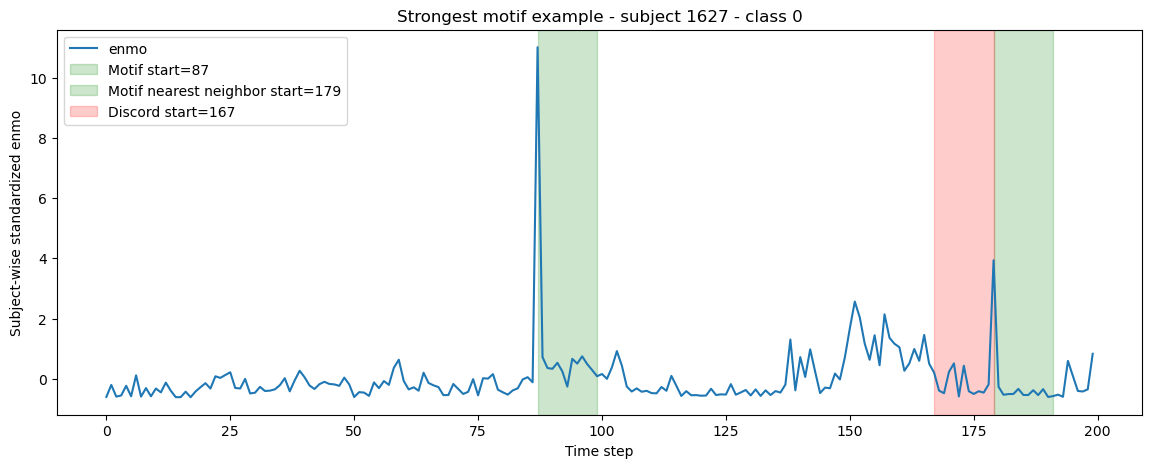

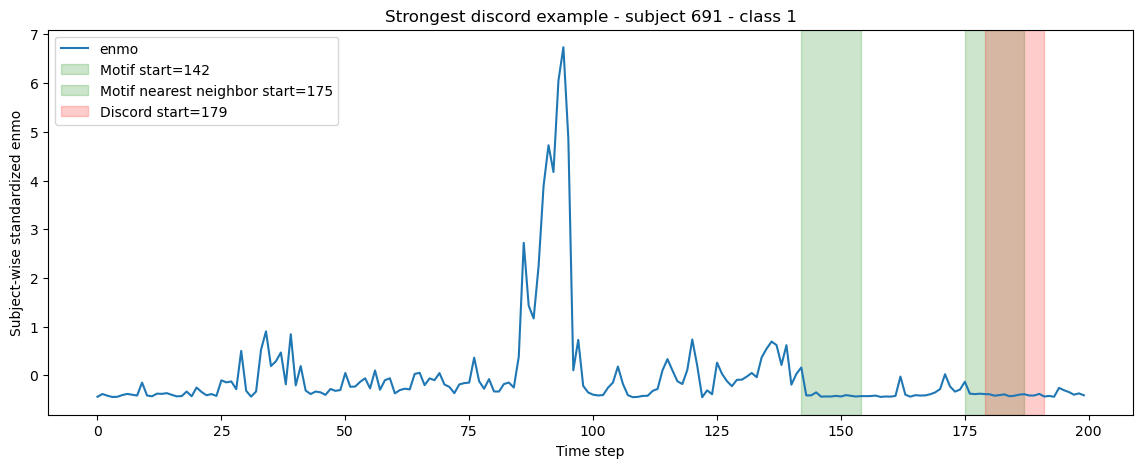

In [17]:
# Plot representative subjects: strongest motif and strongest discord

representative_rows = [
    ("Strongest motif", best_motif_row),
    ("Strongest discord", strongest_discord_row)
]

for title_prefix, row in representative_rows:
    idx = int(row["series_index"])
    ts_df = CMI_timeseries_subject_scaled[idx]
    ts_rep = ts_df[signal_to_analyze].to_numpy().astype(np.float64)

    mp_rep = stumpy.stump(ts_rep, m=m)
    mp_rep_values = mp_rep[:, 0].astype(float)
    mp_rep_indices = mp_rep[:, 1].astype(int)

    motif_start = int(np.argmin(mp_rep_values))
    motif_nn = int(mp_rep_indices[motif_start])
    discord_start = int(np.argmax(mp_rep_values))

    subject_id = ts_df[id_col].iloc[0]
    target = ts_df[target_col].iloc[0]

    plt.figure(figsize=(14, 5))
    plt.plot(ts_rep, label=signal_to_analyze)

    plt.axvspan(
        motif_start,
        motif_start + m,
        alpha=0.20,
        color="green",
        label=f"Motif start={motif_start}"
    )

    plt.axvspan(
        motif_nn,
        motif_nn + m,
        alpha=0.20,
        color="green",
        label=f"Motif nearest neighbor start={motif_nn}"
    )

    plt.axvspan(
        discord_start,
        discord_start + m,
        alpha=0.20,
        color="red",
        label=f"Discord start={discord_start}"
    )

    plt.title(f"{title_prefix} example - subject {subject_id} - class {target}")
    plt.xlabel("Time step")
    plt.ylabel(f"Subject-wise standardized {signal_to_analyze}")
    plt.legend()
    plt.show()

### Dataset-level Matrix Profile results

We extended the Matrix Profile analysis from a single subject to a stratified sample of 100 subjects, with 50 subjects from class `0` and 50 subjects from class `1`.

For each subject, we computed the Matrix Profile of the subject-wise standardized `enmo` signal using subsequence length `m = 12`, corresponding to a 6-hour activity pattern. We then extracted two summary indicators:

- `motif_distance`: the minimum Matrix Profile value, representing the strongest repeated subsequence;
- `discord_distance`: the maximum Matrix Profile value, representing the strongest anomalous subsequence.

The boxplots show that the two classes have highly overlapping distributions for both motif distance and discord distance.

For motif distance, class `1` has a slightly higher average value than class `0`, suggesting that the strongest repeated pattern may be marginally less similar in class `1`. However, the difference is small and the distributions overlap substantially.

For discord distance, the two classes are almost identical. This suggests that the strength of the most anomalous subsequence is not clearly different between problematic and non-problematic subjects in this sample.

Overall, this dataset-level analysis indicates that Matrix Profile is useful for discovering and visualizing repeated or anomalous subsequences, but simple summary statistics such as minimum and maximum Matrix Profile values are not sufficient by themselves to clearly separate the two target classes.

In [18]:
# Cleaner summary table

summary_clean = pd.DataFrame({
    "class": [0, 1],
    "n_subjects": [
        (mp_dataset_results_df["target"] == 0).sum(),
        (mp_dataset_results_df["target"] == 1).sum()
    ],
    "motif_distance_mean": mp_dataset_results_df.groupby("target")["motif_distance"].mean().values,
    "motif_distance_median": mp_dataset_results_df.groupby("target")["motif_distance"].median().values,
    "discord_distance_mean": mp_dataset_results_df.groupby("target")["discord_distance"].mean().values,
    "discord_distance_median": mp_dataset_results_df.groupby("target")["discord_distance"].median().values,
})

display(summary_clean)

,class,n_subjects,motif_distance_mean,motif_distance_median,discord_distance_mean,discord_distance_median
0,0,50,0.901736,0.888482,3.192189,3.190242
1,1,50,0.937241,0.933712,3.175348,3.177164


## Relationship between motifs, discords and shapelets

Motifs, discords and shapelets are all subsequence-based concepts, but they have different objectives.

A **motif** is a repeated subsequence discovered in an unsupervised way. In Matrix Profile analysis, motifs correspond to low Matrix Profile values because they have at least one similar nearest-neighbor subsequence elsewhere in the same time series.

A **discord** is also discovered in an unsupervised way, but it represents an unusual subsequence. In Matrix Profile analysis, discords correspond to high Matrix Profile values because their nearest neighbor is still relatively far away. Therefore, discords identify temporal regions whose shape is unique or anomalous within the time series.

A **shapelet**, instead, is a supervised discriminative subsequence. Shapelets are selected because their presence, absence, or distance from a time series helps distinguish between target classes. Therefore, while motifs and discords describe the internal temporal structure of a time series, shapelets are directly related to classification.

This distinction is important in our analysis. The motifs detected in the selected `enmo` time series represent repeated activity patterns within individual subjects. The detected discords represent unusual activity patterns within individual subjects. However, these subsequences are not automatically useful for classifying subjects as class `0` or class `1`.

The dataset-level analysis supports this interpretation. The distributions of motif distance and discord distance are highly overlapping between the two target classes. This suggests that simple Matrix Profile summaries are useful for describing repeated and anomalous temporal structures, but they are not sufficient by themselves to clearly separate problematic and non-problematic subjects.

Therefore, motifs and discords can be interpreted as exploratory tools, while shapelets should be interpreted as discriminative tools. A motif may become relevant for classification only if a similar repeated pattern is systematically associated with one class. Similarly, a discord may become relevant only if a similar anomalous pattern appears consistently in one class and helps distinguish it from the other.

In this sense, Matrix Profile analysis can support the later shapelet-based classification task. If the shapelets retrieved by a classifier resemble some of the motifs found here, they may represent typical recurring activity patterns associated with one class. If they resemble some of the discords, they may represent unusual but discriminative temporal patterns. However, the final relevance of a subsequence for classification must be assessed through a supervised shapelet model.

In [19]:
# Prepare data for shapelet extraction

from sklearn.model_selection import train_test_split

signal_for_shapelets = "enmo"

n_per_class_shapelets = 40
random_state = 42

shapelet_indices = []

for cls in sorted(subjects_info_df["target"].unique()):
    cls_indices = subjects_info_df[subjects_info_df["target"] == cls]["series_index"]
    sampled = cls_indices.sample(n=n_per_class_shapelets, random_state=random_state).tolist()
    shapelet_indices.extend(sampled)

X_shapelet = []
y_shapelet = []

for idx in shapelet_indices:
    ts_df = CMI_timeseries_subject_scaled[idx]
    X_shapelet.append(ts_df[signal_for_shapelets].to_numpy().astype(np.float64))
    y_shapelet.append(int(ts_df[target_col].iloc[0]))

X_shapelet = np.array(X_shapelet)
y_shapelet = np.array(y_shapelet)

print("X_shapelet shape:", X_shapelet.shape)
print("y_shapelet shape:", y_shapelet.shape)
print("Class distribution:", pd.Series(y_shapelet).value_counts().sort_index().to_dict())

X_shapelet shape: (80, 200)
y_shapelet shape: (80,)
Class distribution: {0: 40, 1: 40}


In [20]:
# Install/import shapelet transformer

import sys

try:
    from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
    print("sktime RandomShapeletTransform is available.")
except ModuleNotFoundError:
    print("sktime not found. Installing...")
    !{sys.executable} -m pip install sktime
    from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
    print("sktime installed and RandomShapeletTransform imported.")

sktime RandomShapeletTransform is available.


In [21]:
# Reshape data for sktime shapelet transformer

X_shapelet_3d = X_shapelet[:, np.newaxis, :]

print("Shapelet input shape:", X_shapelet_3d.shape)

Shapelet input shape: (80, 1, 200)


In [22]:
# Random shapelet extraction

shapelet_transformer = RandomShapeletTransform(
    n_shapelet_samples=500,
    max_shapelets=10,
    min_shapelet_length=8,
    max_shapelet_length=24,
    random_state=random_state,
    n_jobs=-1
)

X_shapelet_transformed = shapelet_transformer.fit_transform(X_shapelet_3d, y_shapelet)

print("Transformed shapelet feature matrix shape:", X_shapelet_transformed.shape)

Transformed shapelet feature matrix shape: (80, 10)


In [23]:
# Inspect available attributes of the fitted shapelet transformer

available_attributes = [
    attr for attr in dir(shapelet_transformer)
    if not attr.startswith("__")
]

for attr in available_attributes:
    if "shape" in attr.lower() or "shapelet" in attr.lower():
        print(attr)

_extract_random_shapelet
_max_shapelet_length
_max_shapelets
_n_shapelet_samples
contract_max_n_shapelet_samples
max_shapelet_length
max_shapelets
min_shapelet_length
n_shapelet_samples
shapelets


In [24]:
# Inspect fitted attributes ending with "_"

fitted_attributes = [
    attr for attr in dir(shapelet_transformer)
    if attr.endswith("_")
]

print("Fitted attributes:")
for attr in fitted_attributes:
    print(attr)

Fitted attributes:
__add__
__class__
__delattr__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__invert__
__le__
__lt__
__module__
__mul__
__ne__
__neg__
__new__
__or__
__radd__
__reduce__
__reduce_ex__
__repr__
__rmul__
__setattr__
__sizeof__
__static_attributes__
__str__
__subclasshook__
__weakref__
_repr_html_
_repr_mimebundle_
classes_


In [25]:
# Inspect extracted shapelets from the fitted transformer

shapelets = shapelet_transformer.shapelets

print("Type of shapelets object:", type(shapelets))
print("Number of extracted shapelets:", len(shapelets))

print("\nFirst shapelet:")
print(shapelets[0])

print("\nType of first shapelet:")
print(type(shapelets[0]))

Type of shapelets object: <class 'list'>
Number of extracted shapelets: 10

First shapelet:
(0.14051905322799998, 21, 99, 0, 20, np.int64(0), array([ 0.82004316,  1.08898166, -0.39463515,  0.28621874,  0.91805743,
       -0.00622734, -0.57032792, -0.61066184, -0.61023349,  1.23888127,
        2.77054758, -0.02143723,  1.01291817, -0.19581659,  0.05860608,
       -1.00376012, -0.8362014 , -0.07662903, -1.20414831, -1.33559181,
       -1.32858387]))

Type of first shapelet:
<class 'tuple'>


In [26]:
# Inspect the structure of the first shapelet

first_shapelet = shapelets[0]

if isinstance(first_shapelet, tuple):
    print("The first shapelet is a tuple.")
    print("Tuple length:", len(first_shapelet))
    
    for i, element in enumerate(first_shapelet):
        print(f"\nElement {i}:")
        print("Type:", type(element))
        print("Value:", element)
else:
    print("The first shapelet is not a tuple.")
    print("Available attributes:")
    
    for attr in dir(first_shapelet):
        if not attr.startswith("__"):
            print(attr)

The first shapelet is a tuple.
Tuple length: 7

Element 0:
Type: <class 'float'>
Value: 0.14051905322799998

Element 1:
Type: <class 'int'>
Value: 21

Element 2:
Type: <class 'int'>
Value: 99

Element 3:
Type: <class 'int'>
Value: 0

Element 4:
Type: <class 'int'>
Value: 20

Element 5:
Type: <class 'numpy.int64'>
Value: 0

Element 6:
Type: <class 'numpy.ndarray'>
Value: [ 0.82004316  1.08898166 -0.39463515  0.28621874  0.91805743 -0.00622734
 -0.57032792 -0.61066184 -0.61023349  1.23888127  2.77054758 -0.02143723
  1.01291817 -0.19581659  0.05860608 -1.00376012 -0.8362014  -0.07662903
 -1.20414831 -1.33559181 -1.32858387]


In [27]:
# Build a readable table of extracted shapelets

shapelet_rows = []

for rank, shp in enumerate(shapelets, start=1):
    score = float(shp[0])
    length = int(shp[1])
    start_pos = int(shp[2])
    series_idx_in_sample = int(shp[3])
    class_or_info = int(shp[4])
    dimension = int(shp[5])
    values = np.asarray(shp[6], dtype=float)

    # Map the internal sample index back to the original dataset index
    original_series_index = shapelet_indices[series_idx_in_sample]
    ts_df = CMI_timeseries_subject_scaled[original_series_index]

    subject_id = ts_df[id_col].iloc[0]
    target = ts_df[target_col].iloc[0]

    shapelet_rows.append({
        "rank": rank,
        "score": score,
        "length": length,
        "start_pos": start_pos,
        "series_idx_in_sample": series_idx_in_sample,
        "original_series_index": original_series_index,
        "subject_id": subject_id,
        "target": target,
        "dimension": dimension,
        "shapelet_values": values
    })

shapelets_df = pd.DataFrame(shapelet_rows)

display(
    shapelets_df.drop(columns=["shapelet_values"])
)

,rank,score,length,start_pos,series_idx_in_sample,original_series_index,subject_id,target,dimension
0,1,0.140519,21,99,0,727,2071,0,0
1,2,0.135431,13,66,0,727,2071,0,1
2,3,0.128072,22,161,0,727,2071,0,0
3,4,0.122815,17,90,0,727,2071,0,1
4,5,0.122815,11,26,0,727,2071,0,0
5,6,0.119054,22,30,0,727,2071,0,0
6,7,0.115281,22,11,0,727,2071,0,0
7,8,0.113844,16,8,0,727,2071,0,1
8,9,0.110349,19,126,0,727,2071,0,1
9,10,0.101236,13,62,0,727,2071,0,1


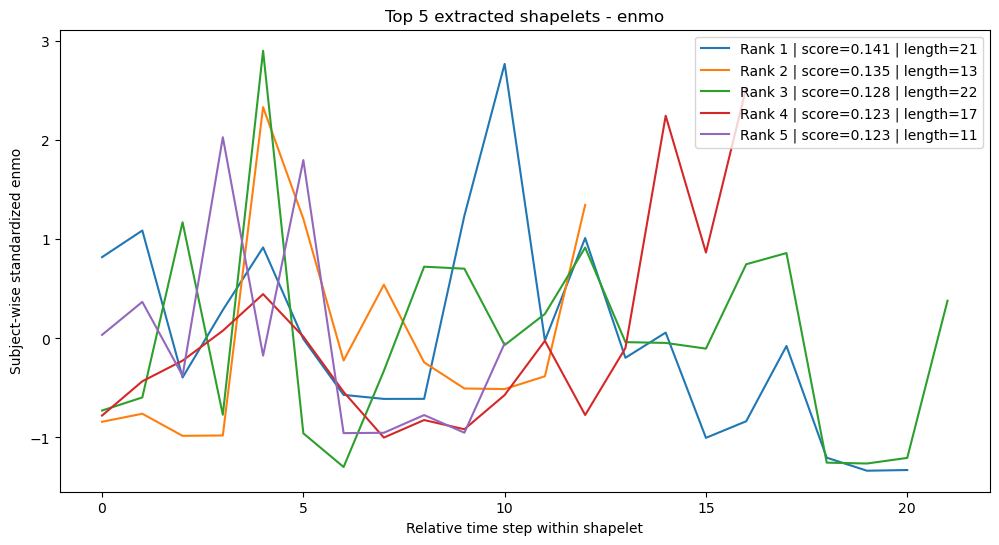

In [28]:
# Visualize top extracted shapelets

top_n_shapelets = 5

plt.figure(figsize=(12, 6))

for _, row in shapelets_df.head(top_n_shapelets).iterrows():
    values = row["shapelet_values"]
    rank = int(row["rank"])
    score = row["score"]
    length = int(row["length"])
    
    plt.plot(
        values,
        label=f"Rank {rank} | score={score:.3f} | length={length}"
    )

plt.title(f"Top {top_n_shapelets} extracted shapelets - {signal_for_shapelets}")
plt.xlabel("Relative time step within shapelet")
plt.ylabel(f"Subject-wise standardized {signal_for_shapelets}")
plt.legend()
plt.show()

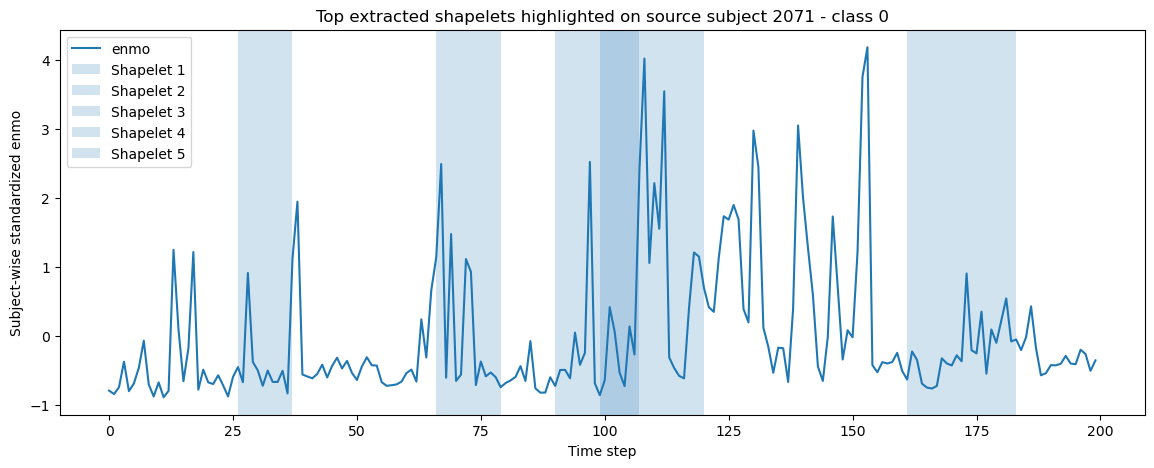

In [29]:
# Highlight extracted shapelets on their source time series

source_series_index = int(shapelets_df.iloc[0]["original_series_index"])
source_ts_df = CMI_timeseries_subject_scaled[source_series_index]
source_ts = source_ts_df[signal_for_shapelets].to_numpy().astype(np.float64)

source_subject_id = source_ts_df[id_col].iloc[0]
source_target = source_ts_df[target_col].iloc[0]

plt.figure(figsize=(14, 5))
plt.plot(source_ts, label=signal_for_shapelets)

for _, row in shapelets_df.head(top_n_shapelets).iterrows():
    rank = int(row["rank"])
    start = int(row["start_pos"])
    length = int(row["length"])
    
    plt.axvspan(
        start,
        start + length,
        alpha=0.20,
        label=f"Shapelet {rank}"
    )

plt.title(
    f"Top extracted shapelets highlighted on source subject {source_subject_id} - class {source_target}"
)
plt.xlabel("Time step")
plt.ylabel(f"Subject-wise standardized {signal_for_shapelets}")
plt.legend()
plt.show()

In [30]:
RandomShapeletTransform(
    n_shapelet_samples=1000,
    max_shapelets=10,
    min_shapelet_length=8,
    max_shapelet_length=24,
    random_state=random_state,
    n_jobs=-1
)

RandomShapeletTransform(max_shapelet_length=24, max_shapelets=10,
                        min_shapelet_length=8, n_jobs=-1,
                        n_shapelet_samples=1000, random_state=42)

In [31]:
# Random shapelet extraction - more robust run

shapelet_transformer = RandomShapeletTransform(
    n_shapelet_samples=1000,
    max_shapelets=10,
    min_shapelet_length=8,
    max_shapelet_length=24,
    random_state=random_state,
    n_jobs=-1
)

X_shapelet_transformed = shapelet_transformer.fit_transform(
    X_shapelet_3d,
    y_shapelet
)

print("Transformed shapelet feature matrix shape:", X_shapelet_transformed.shape)

Transformed shapelet feature matrix shape: (80, 9)


In [32]:
# Inspect extracted shapelets from the fitted transformer

shapelets = shapelet_transformer.shapelets

print("Number of extracted shapelets:", len(shapelets))
print("\nFirst shapelet:")
print(shapelets[0])

Number of extracted shapelets: 9

First shapelet:
(0.153379814206, 19, 118, 0, 13, np.int64(0), array([ 0.73224873,  1.94471284,  0.76836377, -0.13913081,  0.60106193,
        0.68749798, -0.67635063, -1.08888052, -1.06883226, -1.02485813,
       -0.49877667, -0.90169829, -0.31186801,  0.50507808, -0.68126864,
       -0.58009615, -0.48314561, -0.39184798,  2.60779036]))


In [33]:
# Build a readable table of extracted shapelets

shapelet_rows = []

for rank, shp in enumerate(shapelets, start=1):
    score = float(shp[0])
    length = int(shp[1])
    start_pos = int(shp[2])
    series_idx_in_sample = int(shp[3])
    class_or_info = int(shp[4])
    dimension = int(shp[5])
    values = np.asarray(shp[6], dtype=float)

    # Map the internal sample index back to the original dataset index
    original_series_index = shapelet_indices[series_idx_in_sample]
    ts_df = CMI_timeseries_subject_scaled[original_series_index]

    subject_id = ts_df[id_col].iloc[0]
    target = ts_df[target_col].iloc[0]

    shapelet_rows.append({
        "rank": rank,
        "score": score,
        "length": length,
        "start_pos": start_pos,
        "series_idx_in_sample": series_idx_in_sample,
        "original_series_index": original_series_index,
        "subject_id": subject_id,
        "target": target,
        "dimension": dimension,
        "shapelet_values": values
    })

shapelets_df = pd.DataFrame(shapelet_rows)

display(
    shapelets_df.drop(columns=["shapelet_values"])
)

,rank,score,length,start_pos,series_idx_in_sample,original_series_index,subject_id,target,dimension
0,1,0.153380,19,118,0,727,2071,0,0
1,2,0.140519,21,99,0,727,2071,0,0
2,3,0.135431,13,66,0,727,2071,0,1
3,4,0.128072,22,161,0,727,2071,0,0
4,5,0.122815,18,38,0,727,2071,0,0
5,6,0.122815,17,90,0,727,2071,0,1
6,7,0.122815,13,57,0,727,2071,0,1
7,8,0.113844,16,8,0,727,2071,0,1
8,9,0.110411,12,13,0,727,2071,0,1


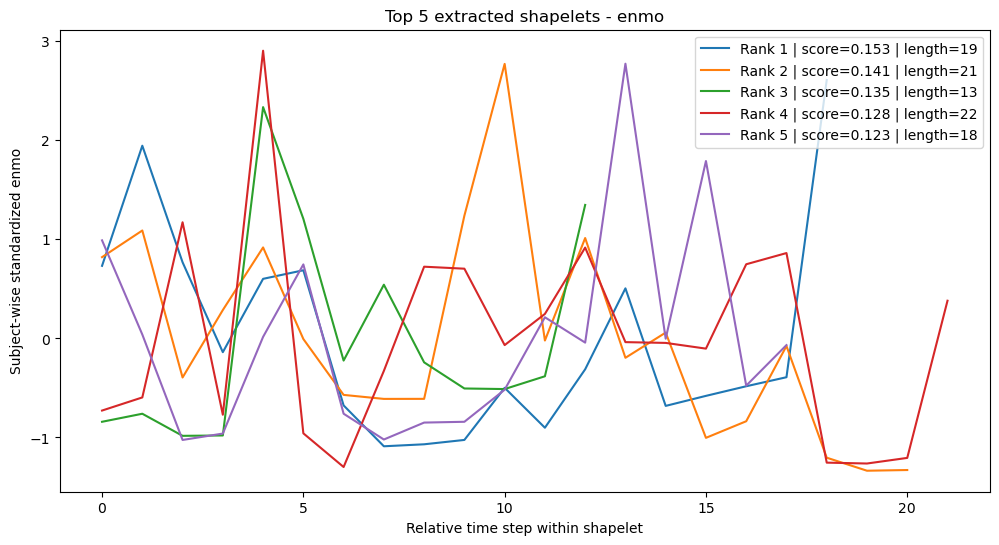

In [34]:
# Visualize top extracted shapelets

top_n_shapelets = min(5, len(shapelets_df))

plt.figure(figsize=(12, 6))

for _, row in shapelets_df.head(top_n_shapelets).iterrows():
    values = row["shapelet_values"]
    rank = int(row["rank"])
    score = row["score"]
    length = int(row["length"])
    
    plt.plot(
        values,
        label=f"Rank {rank} | score={score:.3f} | length={length}"
    )

plt.title(f"Top {top_n_shapelets} extracted shapelets - {signal_for_shapelets}")
plt.xlabel("Relative time step within shapelet")
plt.ylabel(f"Subject-wise standardized {signal_for_shapelets}")
plt.legend()
plt.show()

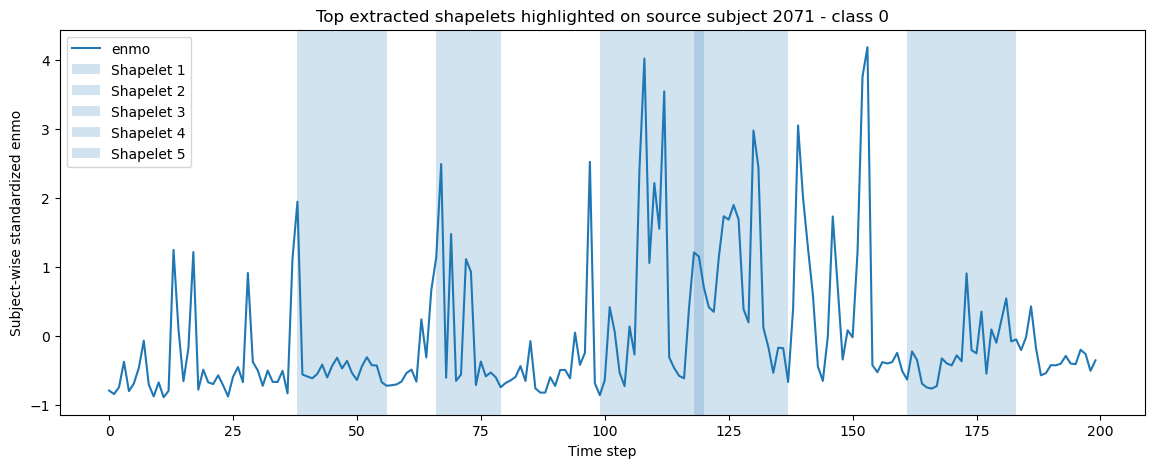

In [35]:
# Highlight extracted shapelets on their source time series

source_series_index = int(shapelets_df.iloc[0]["original_series_index"])
source_ts_df = CMI_timeseries_subject_scaled[source_series_index]
source_ts = source_ts_df[signal_for_shapelets].to_numpy().astype(np.float64)

source_subject_id = source_ts_df[id_col].iloc[0]
source_target = source_ts_df[target_col].iloc[0]

plt.figure(figsize=(14, 5))
plt.plot(source_ts, label=signal_for_shapelets)

for _, row in shapelets_df.head(top_n_shapelets).iterrows():
    rank = int(row["rank"])
    start = int(row["start_pos"])
    length = int(row["length"])
    
    plt.axvspan(
        start,
        start + length,
        alpha=0.20,
        label=f"Shapelet {rank}"
    )

plt.title(
    f"Top extracted shapelets highlighted on source subject {source_subject_id} - class {source_target}"
)
plt.xlabel("Time step")
plt.ylabel(f"Subject-wise standardized {signal_for_shapelets}")
plt.legend()
plt.show()

In [36]:
# Check source subjects and classes of extracted shapelets

print("Shapelets by source subject:")
display(
    shapelets_df
    .groupby(["subject_id", "target"])
    .size()
    .reset_index(name="n_shapelets")
    .sort_values("n_shapelets", ascending=False)
)

print("Shapelets by target class:")
display(
    shapelets_df["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="n_shapelets")
)

Shapelets by source subject:


,subject_id,target,n_shapelets
0,2071,0,9


Shapelets by target class:


,target,n_shapelets
0,0,9


In [37]:
# Check whether subject 2071 was unusual in previous preprocessing / anomaly summaries

subject_to_check = 2071

# Find the subject in the preprocessed dataset
matches = []

for i, ts_df in enumerate(CMI_timeseries_subject_scaled):
    if ts_df[id_col].iloc[0] == subject_to_check:
        matches.append(i)

print("Matching series indices:", matches)

idx_2071 = matches[0]
ts_2071 = CMI_timeseries_subject_scaled[idx_2071]

print("Target:", ts_2071[target_col].iloc[0])
print("Shape:", ts_2071.shape)

display(ts_2071[signal_cols].describe())

Matching series indices: [438, 655, 727, 966, 1429, 1471, 1620, 1786, 1916, 2030, 2052, 2393, 2476, 2770, 2907, 3092, 3117, 3182, 3261, 3532, 3550, 3618, 3621, 4188, 4243]
Target: 0
Shape: (200, 13)


,X,Y,Z,enmo,anglez,light
count,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,0.000000,-1.907349e-08,-1.907349e-08,-1.907349e-08,1.907349e-08,-9.536743e-09
std,1.002509,1.002509e+00,1.002509e+00,1.002509e+00,1.002510e+00,1.002509e+00
min,-1.633016,-1.822668e+00,-2.647745e+00,-9.758883e-01,-2.614513e+00,-5.625412e-01
25%,-0.798730,-8.202915e-01,-6.454077e-01,-7.099262e-01,-6.789404e-01,-4.235429e-01
50%,-0.334761,-6.844219e-03,-6.483192e-02,-4.347640e-01,-9.380500e-02,-2.890304e-01
75%,1.006955,6.253691e-01,6.589947e-01,4.295905e-01,5.594135e-01,-4.513181e-02
max,2.224149,2.690727e+00,1.908470e+00,5.032520e+00,2.169639e+00,7.462581e+00


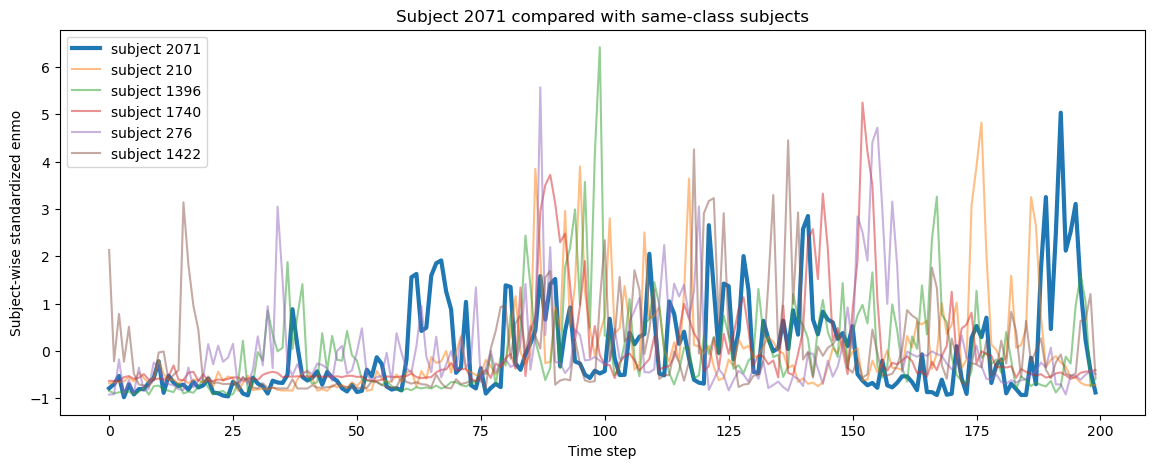

In [38]:
# Compare subject 2071 with random subjects from the same class

target_2071 = ts_2071[target_col].iloc[0]

same_class_indices = [
    i for i, ts_df in enumerate(CMI_timeseries_subject_scaled)
    if ts_df[target_col].iloc[0] == target_2071 and ts_df[id_col].iloc[0] != subject_to_check
]

sample_same_class = np.random.default_rng(42).choice(
    same_class_indices,
    size=5,
    replace=False
)

plt.figure(figsize=(14, 5))

plt.plot(
    ts_2071[signal_for_shapelets].to_numpy(),
    linewidth=3,
    label=f"subject {subject_to_check}"
)

for idx in sample_same_class:
    ts_df = CMI_timeseries_subject_scaled[idx]
    plt.plot(
        ts_df[signal_for_shapelets].to_numpy(),
        alpha=0.5,
        label=f"subject {ts_df[id_col].iloc[0]}"
    )

plt.title(f"Subject {subject_to_check} compared with same-class subjects")
plt.xlabel("Time step")
plt.ylabel(f"Subject-wise standardized {signal_for_shapelets}")
plt.legend()
plt.show()

In [39]:
# Check if subject 2071 appears in the dataset-level Matrix Profile sample

mp_dataset_results_df[
    mp_dataset_results_df["subject_id"] == subject_to_check
]

,series_index,subject_id,target,motif_distance,discord_distance,motif_start,discord_start
0,727,2071,0,0.648415,3.22774,38,43
43,3550,2071,0,0.420394,3.26783,157,70


In [40]:
# Check duplicated subject IDs in the preprocessed time-series dataset

id_summary = []

for i, ts_df in enumerate(CMI_timeseries_subject_scaled):
    id_summary.append({
        "series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    })

id_summary_df = pd.DataFrame(id_summary)

id_counts = (
    id_summary_df
    .groupby("subject_id")
    .size()
    .reset_index(name="n_series")
    .sort_values("n_series", ascending=False)
)

print("Number of unique subject IDs:", id_summary_df["subject_id"].nunique())
print("Number of time series:", len(id_summary_df))
print("Number of duplicated subject IDs:", (id_counts["n_series"] > 1).sum())

display(id_counts.head(20))

Number of unique subject IDs: 375
Number of time series: 4310
Number of duplicated subject IDs: 247


,subject_id,n_series
203,2043,36
198,1935,35
21,210,34
265,2712,34
83,736,33
157,1397,33
67,633,33
151,1328,33
36,339,32
95,835,32


In [41]:
# Check whether duplicated subject IDs have consistent target labels

target_consistency = (
    id_summary_df
    .groupby("subject_id")["target"]
    .nunique()
    .reset_index(name="n_unique_targets")
    .sort_values("n_unique_targets", ascending=False)
)

display(target_consistency.head(20))

print(
    "Number of subject IDs with inconsistent targets:",
    (target_consistency["n_unique_targets"] > 1).sum()
)

,subject_id,n_unique_targets
0,3,1
247,2489,1
256,2592,1
255,2574,1
254,2566,1
253,2548,1
252,2541,1
251,2538,1
250,2496,1
249,2495,1


Number of subject IDs with inconsistent targets: 0


### Note on repeated subject IDs

The dataset contains 4,310 time series but only 375 unique subject IDs. This means that several subjects contribute more than one time-series window to the dataset.

The duplicated subject IDs have consistent target labels, since each subject ID is associated with only one target value. Therefore, repeated IDs do not indicate contradictory labels or invalid observations.

This is important for interpretation. In the motif/discord analysis, each time series can be analyzed independently because Matrix Profile identifies repeated and anomalous subsequences within a single sequence. However, for supervised classification tasks, repeated subject IDs must be handled carefully to avoid data leakage. In particular, future train/test splits should be performed at the subject level, using the subject ID as a grouping variable.

Subject 2071, from which the exploratory shapelets were extracted, is therefore not removed. Its repeated occurrence and influence in the shapelet extraction are interpreted as properties of the sampled windows rather than evidence of invalid data.

In [42]:
# Extract top-k discords from the full Matrix Profile
# Standard approach: do not remove motif regions.
# We only apply an exclusion zone between selected discords to avoid overlapping subsequences.

def extract_top_k_discords(mp_values, k=3, exclusion_zone=None):
    """
    Extract top-k discords from a Matrix Profile.

    Parameters
    ----------
    mp_values : np.ndarray
        Matrix Profile values.
    k : int
        Number of discords to extract.
    exclusion_zone : int or None
        Exclusion zone around each selected discord. If None, uses m.

    Returns
    -------
    discord_indices : list[int]
        Starting indices of selected discord subsequences.
    discord_distances : list[float]
        Matrix Profile values of selected discords.
    """
    if exclusion_zone is None:
        exclusion_zone = m

    mp_copy = mp_values.astype(float).copy()
    discord_indices = []
    discord_distances = []

    for _ in range(k):
        if np.all(np.isneginf(mp_copy)):
            break

        discord_idx = int(np.argmax(mp_copy))
        discord_dist = float(mp_values[discord_idx])

        discord_indices.append(discord_idx)
        discord_distances.append(discord_dist)

        start = max(0, discord_idx - exclusion_zone)
        end = min(len(mp_copy), discord_idx + exclusion_zone + 1)

        # Prevent selecting overlapping / near-overlapping discords
        mp_copy[start:end] = -np.inf

    return discord_indices, discord_distances


top_k_discords, top_k_discord_distances = extract_top_k_discords(
    mp_values=mp_values,
    k=3,
    exclusion_zone=m
)

print("Top-k discords:")
for rank, (idx, dist) in enumerate(zip(top_k_discords, top_k_discord_distances), start=1):
    print(f"Rank {rank}: start={idx}, Matrix Profile distance={dist:.4f}")

Top-k discords:
Rank 1: start=167, Matrix Profile distance=3.2542
Rank 2: start=46, Matrix Profile distance=3.0586
Rank 3: start=27, Matrix Profile distance=2.9505


In [43]:
# Summary table for extracted motifs and discords

analysis_rows = []

# Motif pair already obtained from Matrix Profile
# Assumes these variables already exist:
# motif_start, motif_nn, motif_distance
# top_k_discords, top_k_discord_distances
# m

analysis_rows.append({
    "type": "motif",
    "rank": 1,
    "start": int(motif_start),
    "end": int(motif_start + m),
    "distance": float(motif_distance),
    "role": "motif representative"
})

analysis_rows.append({
    "type": "motif_nearest_neighbor",
    "rank": 1,
    "start": int(motif_nn),
    "end": int(motif_nn + m),
    "distance": float(motif_distance),
    "role": "nearest neighbor of motif"
})

for rank, (idx, dist) in enumerate(zip(top_k_discords, top_k_discord_distances), start=1):
    analysis_rows.append({
        "type": "discord",
        "rank": rank,
        "start": int(idx),
        "end": int(idx + m),
        "distance": float(dist),
        "role": f"discord rank {rank}"
    })

motif_discord_summary_df = pd.DataFrame(analysis_rows)

display(motif_discord_summary_df)

,type,rank,start,end,distance,role
0,motif,1,142,154,1.113824,motif representative
1,motif_nearest_neighbor,1,175,187,1.113824,nearest neighbor of motif
2,discord,1,167,179,3.254196,discord rank 1
3,discord,2,46,58,3.058591,discord rank 2
4,discord,3,27,39,2.950547,discord rank 3


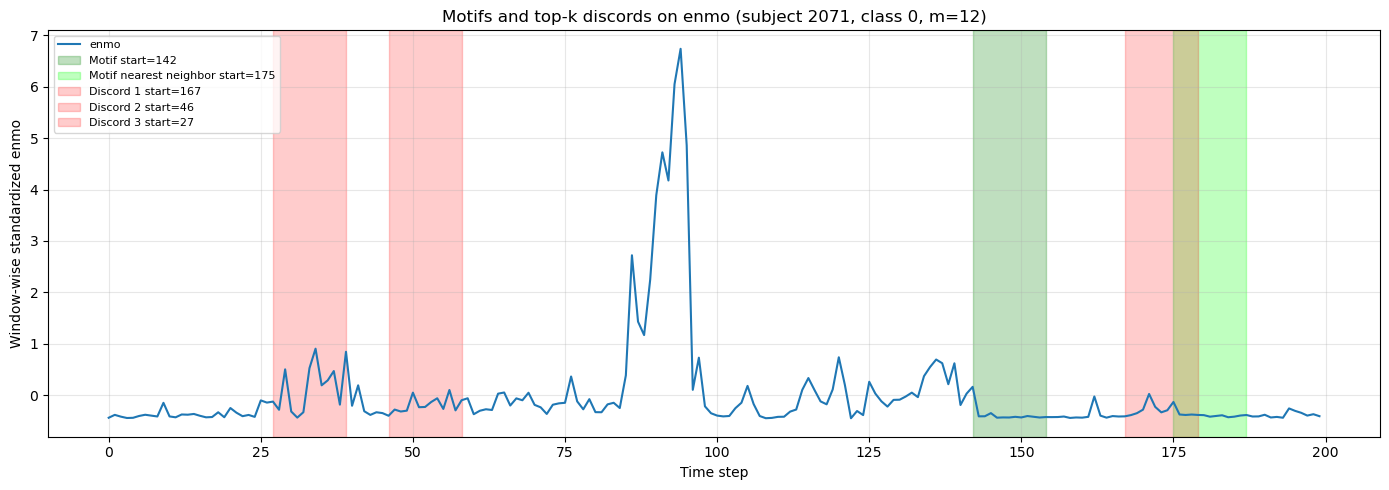

In [44]:
# Plot full time series with motif pair and top-k discords

plt.figure(figsize=(14, 5))

plt.plot(
    ts_rep,
    label=signal_to_analyze,
    linewidth=1.5
)

# Motif representative
plt.axvspan(
    motif_start,
    motif_start + m,
    alpha=0.25,
    color="green",
    label=f"Motif start={motif_start}"
)

# Motif nearest neighbor
plt.axvspan(
    motif_nn,
    motif_nn + m,
    alpha=0.25,
    color="lime",
    label=f"Motif nearest neighbor start={motif_nn}"
)

# Discords
for rank, idx in enumerate(top_k_discords, start=1):
    plt.axvspan(
        idx,
        idx + m,
        alpha=0.20,
        color="red",
        label=f"Discord {rank} start={idx}"
    )

plt.title(
    f"Motifs and top-k discords on {signal_to_analyze} "
    f"(subject {subject_id}, class {target}, m={m})"
)
plt.xlabel("Time step")
plt.ylabel(f"Window-wise standardized {signal_to_analyze}")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

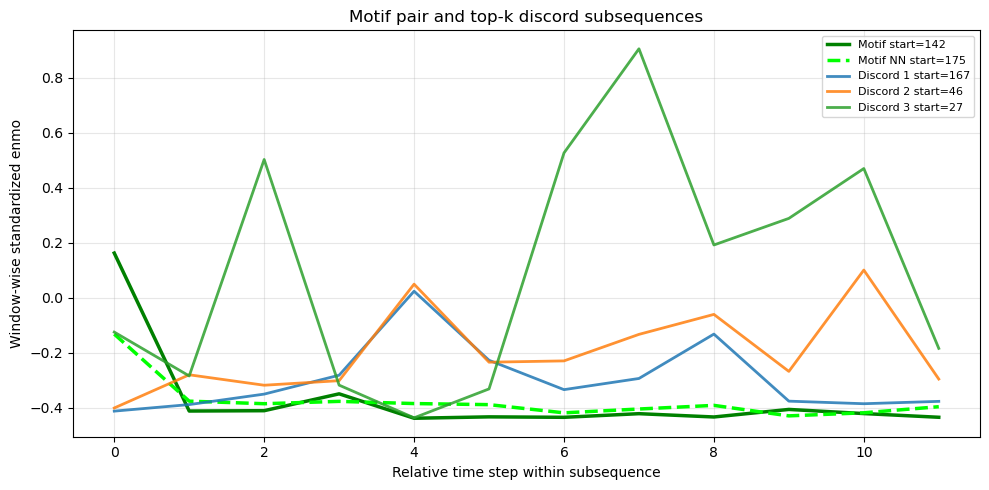

In [45]:
# Compare extracted subsequences on relative time axis

plt.figure(figsize=(10, 5))

# Motif subsequences
motif_subseq = ts_rep[motif_start:motif_start + m]
motif_nn_subseq = ts_rep[motif_nn:motif_nn + m]

plt.plot(
    motif_subseq,
    linewidth=2.5,
    label=f"Motif start={motif_start}",
    color="green"
)

plt.plot(
    motif_nn_subseq,
    linewidth=2.5,
    linestyle="--",
    label=f"Motif NN start={motif_nn}",
    color="lime"
)

# Discord subsequences
for rank, idx in enumerate(top_k_discords, start=1):
    discord_subseq = ts_rep[idx:idx + m]
    plt.plot(
        discord_subseq,
        linewidth=2,
        alpha=0.85,
        label=f"Discord {rank} start={idx}"
    )

plt.title("Motif pair and top-k discord subsequences")
plt.xlabel("Relative time step within subsequence")
plt.ylabel(f"Window-wise standardized {signal_to_analyze}")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

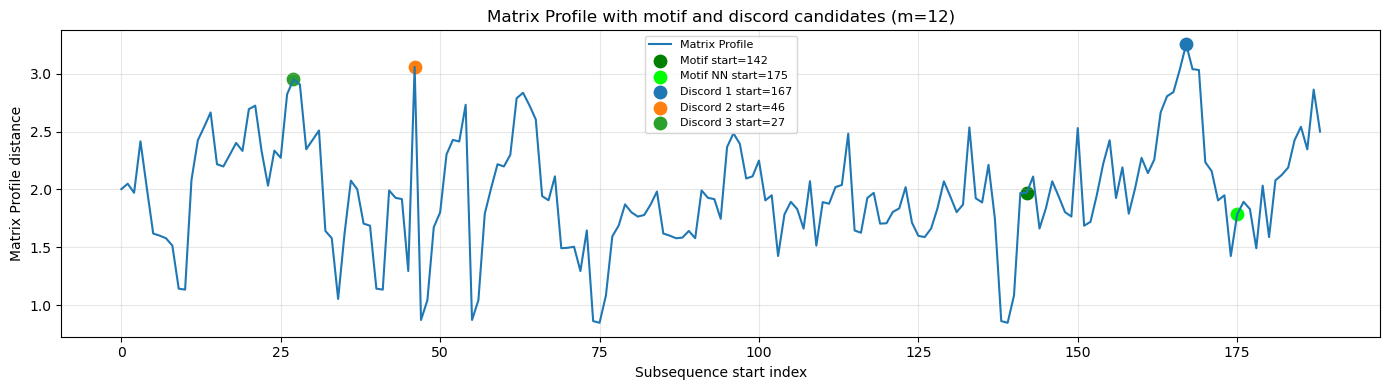

In [46]:
# Plot Matrix Profile with motif and discord locations

plt.figure(figsize=(14, 4))

plt.plot(
    mp_values,
    label="Matrix Profile",
    linewidth=1.5
)

plt.scatter(
    motif_start,
    mp_values[motif_start],
    color="green",
    s=80,
    label=f"Motif start={motif_start}"
)

plt.scatter(
    motif_nn,
    mp_values[motif_nn],
    color="lime",
    s=80,
    label=f"Motif NN start={motif_nn}"
)

for rank, idx in enumerate(top_k_discords, start=1):
    plt.scatter(
        idx,
        mp_values[idx],
        s=80,
        label=f"Discord {rank} start={idx}"
    )

plt.title(f"Matrix Profile with motif and discord candidates (m={m})")
plt.xlabel("Subsequence start index")
plt.ylabel("Matrix Profile distance")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Numerical characterization of motif and discord subsequences

subseq_rows = []

def summarize_subsequence(values, label, rank, start, distance):
    return {
        "type": label,
        "rank": rank,
        "start": int(start),
        "end": int(start + len(values)),
        "distance": float(distance),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
        "range": float(np.max(values) - np.min(values)),
        "first_value": float(values[0]),
        "last_value": float(values[-1]),
        "slope_last_minus_first": float(values[-1] - values[0])
    }

subseq_rows.append(
    summarize_subsequence(
        motif_subseq,
        label="motif",
        rank=1,
        start=motif_start,
        distance=motif_distance
    )
)

subseq_rows.append(
    summarize_subsequence(
        motif_nn_subseq,
        label="motif_nearest_neighbor",
        rank=1,
        start=motif_nn,
        distance=motif_distance
    )
)

for rank, (idx, dist) in enumerate(zip(top_k_discords, top_k_discord_distances), start=1):
    discord_subseq = ts_rep[idx:idx + m]

    subseq_rows.append(
        summarize_subsequence(
            discord_subseq,
            label="discord",
            rank=rank,
            start=idx,
            distance=dist
        )
    )

subsequence_characterization_df = pd.DataFrame(subseq_rows)

display(subsequence_characterization_df)

,type,rank,start,end,distance,mean,std,min,max,range,first_value,last_value,slope_last_minus_first
0,motif,1,142,154,1.113824,-0.368849,0.161833,-0.437564,0.162413,0.599977,0.162413,-0.434021,-0.596434
1,motif_nearest_neighbor,1,175,187,1.113824,-0.374644,0.075024,-0.428898,-0.131898,0.297000,-0.131898,-0.395632,-0.263734
2,discord,1,167,179,3.254196,-0.294086,0.122789,-0.411683,0.023807,0.435490,-0.411683,-0.376236,0.035447
3,discord,2,46,58,3.058591,-0.197293,0.147969,-0.400279,0.100723,0.501002,-0.400279,-0.295248,0.105031
4,discord,3,27,39,2.950547,0.100496,0.417987,-0.436027,0.904387,1.340414,-0.124561,-0.183784,-0.059223


In [48]:
# Compare motif/discord subsequences against full-window distribution

window_mean = np.mean(ts_rep)
window_std = np.std(ts_rep)
window_min = np.min(ts_rep)
window_max = np.max(ts_rep)

comparison_df = subsequence_characterization_df.copy()

comparison_df["mean_vs_window_mean"] = comparison_df["mean"] - window_mean
comparison_df["max_vs_window_max"] = comparison_df["max"] - window_max
comparison_df["min_vs_window_min"] = comparison_df["min"] - window_min
comparison_df["std_vs_window_std"] = comparison_df["std"] - window_std

print("Full window summary:")
print(f"mean={window_mean:.3f}, std={window_std:.3f}, min={window_min:.3f}, max={window_max:.3f}")

display(comparison_df)

Full window summary:
mean=0.000, std=1.000, min=-0.449, max=6.736


,type,rank,start,end,distance,mean,std,min,max,range,first_value,last_value,slope_last_minus_first,mean_vs_window_mean,max_vs_window_max,min_vs_window_min,std_vs_window_std
0,motif,1,142,154,1.113824,-0.368849,0.161833,-0.437564,0.162413,0.599977,0.162413,-0.434021,-0.596434,-0.368849,-6.573893,0.011054,-0.838167
1,motif_nearest_neighbor,1,175,187,1.113824,-0.374644,0.075024,-0.428898,-0.131898,0.297000,-0.131898,-0.395632,-0.263734,-0.374644,-6.868205,0.019721,-0.924976
2,discord,1,167,179,3.254196,-0.294086,0.122789,-0.411683,0.023807,0.435490,-0.411683,-0.376236,0.035447,-0.294086,-6.712499,0.036936,-0.877211
3,discord,2,46,58,3.058591,-0.197293,0.147969,-0.400279,0.100723,0.501002,-0.400279,-0.295248,0.105031,-0.197293,-6.635584,0.048339,-0.852031
4,discord,3,27,39,2.950547,0.100496,0.417987,-0.436027,0.904387,1.340414,-0.124561,-0.183784,-0.059223,0.100496,-5.831920,0.012591,-0.582013


In [49]:
# Check overlap between motif regions and discord regions

def intervals_overlap(start_a, length_a, start_b, length_b):
    end_a = start_a + length_a
    end_b = start_b + length_b
    return max(start_a, start_b) < min(end_a, end_b)

overlap_rows = []

for rank, idx in enumerate(top_k_discords, start=1):
    overlap_rows.append({
        "discord_rank": rank,
        "discord_start": idx,
        "overlaps_motif": intervals_overlap(idx, m, motif_start, m),
        "overlaps_motif_nearest_neighbor": intervals_overlap(idx, m, motif_nn, m)
    })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)

,discord_rank,discord_start,overlaps_motif,overlaps_motif_nearest_neighbor
0,1,167,False,True
1,2,46,False,False
2,3,27,False,False


## Clustering sui Motifs

In [50]:
# Extract top motif from each time-series window and use it as feature vector

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
import stumpy

# Main settings
motif_signal = "enmo"
motif_m = 12   # same Matrix Profile subsequence length used before

motif_feature_rows = []
motif_vectors = []

for series_index, ts_df in tqdm(
    enumerate(CMI_timeseries_subject_scaled),
    total=len(CMI_timeseries_subject_scaled),
    desc="Extracting top motif per window"
):
    x = ts_df[motif_signal].to_numpy().astype(np.float64)

    # Safety: skip impossible cases
    if len(x) < motif_m + 1:
        continue

    mp = stumpy.stump(x, m=motif_m)

    mp_values = mp[:, 0].astype(float)
    mp_indices = mp[:, 1].astype(int)

    # Top motif = subsequence with minimum Matrix Profile value
    motif_start = int(np.nanargmin(mp_values))
    motif_nn = int(mp_indices[motif_start])
    motif_distance = float(mp_values[motif_start])

    motif_subseq = x[motif_start:motif_start + motif_m]
    motif_nn_subseq = x[motif_nn:motif_nn + motif_m]

    # Store motif shape as feature vector
    motif_vectors.append(motif_subseq)

    motif_feature_rows.append({
        "series_index": series_index,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0],
        "motif_start": motif_start,
        "motif_nearest_neighbor": motif_nn,
        "motif_distance": motif_distance,
        "motif_mean": np.mean(motif_subseq),
        "motif_std": np.std(motif_subseq),
        "motif_min": np.min(motif_subseq),
        "motif_max": np.max(motif_subseq),
        "motif_range": np.max(motif_subseq) - np.min(motif_subseq),
        "motif_slope": motif_subseq[-1] - motif_subseq[0],
        "motif_values": motif_subseq,
        "motif_nn_values": motif_nn_subseq
    })

motif_features_df = pd.DataFrame(motif_feature_rows)
X_motif_shape = np.vstack(motif_vectors)

print("Motif feature dataframe shape:", motif_features_df.shape)
print("Motif shape matrix:", X_motif_shape.shape)

display(motif_features_df.head())

Extracting top motif per window: 100%|██████████| 4310/4310 [00:07<00:00, 552.48it/s]

Motif feature dataframe shape: (4310, 14)
Motif shape matrix: (4310, 12)


,series_index,subject_id,target,motif_start,motif_nearest_neighbor,motif_distance,motif_mean,motif_std,motif_min,motif_max,motif_range,motif_slope,motif_values,motif_nn_values
0,0,2265,0,75,139,0.846990,-0.175796,0.573438,-0.572449,1.408813,1.981263,0.771009,"[-0.5171589255332947, -0.45812085270881653, -0...","[-0.7621271014213562, -0.5465260148048401, -0...."
1,1,3042,1,59,107,0.709135,0.385200,1.645035,-0.599945,5.696889,6.296834,5.534811,"[0.1620778739452362, -0.3864987790584564, 0.32...","[-0.283986896276474, -0.42003434896469116, -0...."
2,2,1647,1,95,112,0.737163,0.993447,1.796685,-0.617891,4.571598,5.189489,5.084295,"[-0.6178911328315735, -0.5003734230995178, 0.7...","[-0.6238744258880615, -0.5998545289039612, -0...."
3,3,736,0,77,123,0.997706,-0.311432,0.216173,-0.563762,0.174831,0.738593,-0.179899,"[-0.3289884924888611, -0.3900838792324066, -0....","[-0.36045408248901367, -0.06268193572759628, 0..."
4,4,1044,0,52,71,0.890845,-0.273141,0.525404,-0.789563,0.819595,1.609158,-0.185058,"[-0.5764867067337036, -0.5410305857658386, -0....","[0.08253365010023117, 0.6000686883926392, -0.0..."


In [52]:
# Build motif-based feature matrices

from sklearn.preprocessing import StandardScaler

# Shape-only motif features
X_motif_shape_df = pd.DataFrame(
    X_motif_shape,
    columns=[f"motif_t{i}" for i in range(X_motif_shape.shape[1])]
)

# Summary descriptors
motif_summary_cols = [
    "motif_distance",
    "motif_mean",
    "motif_std",
    "motif_min",
    "motif_max",
    "motif_range",
    "motif_slope"
]

X_motif_summary_df = motif_features_df[motif_summary_cols].copy()

# Combined features
X_motif_combined_df = pd.concat(
    [
        X_motif_shape_df.reset_index(drop=True),
        X_motif_summary_df.reset_index(drop=True)
    ],
    axis=1
)

# Scale features before KMeans
scaler_motif_shape = StandardScaler()
X_motif_shape_scaled = scaler_motif_shape.fit_transform(X_motif_shape_df)

scaler_motif_combined = StandardScaler()
X_motif_combined_scaled = scaler_motif_combined.fit_transform(X_motif_combined_df)

y_motif = motif_features_df["target"].to_numpy()

print("Shape-only motif features:", X_motif_shape_scaled.shape)
print("Combined motif features:", X_motif_combined_scaled.shape)

Shape-only motif features: (4310, 12)
Combined motif features: (4310, 19)


In [53]:
# KMeans clustering on motif-based feature vectors

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

k_values = [2, 3, 4, 5, 6, 8, 10]

motif_kmeans_results = []

feature_spaces = {
    "motif_shape_only": X_motif_shape_scaled,
    "motif_shape_plus_summary": X_motif_combined_scaled
}

for representation_name, X_features in feature_spaces.items():
    for k in k_values:
        print(f"Fitting KMeans on {representation_name}, k={k}")

        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=20
        )

        labels = model.fit_predict(X_features)

        sil = silhouette_score(X_features, labels)
        ari = adjusted_rand_score(y_motif, labels)
        nmi = normalized_mutual_info_score(y_motif, labels)

        counts = pd.Series(labels).value_counts()

        motif_kmeans_results.append({
            "method": "KMeans",
            "representation": representation_name,
            "k": k,
            "silhouette": sil,
            "ARI_vs_target": ari,
            "NMI_vs_target": nmi,
            "min_cluster_size": counts.min(),
            "max_cluster_size": counts.max(),
            "imbalance_ratio": counts.max() / counts.min(),
            "labels": labels,
            "model": model,
            "X_features": X_features
        })

motif_kmeans_results_df = pd.DataFrame([
    {key: value for key, value in row.items() if key not in ["labels", "model", "X_features"]}
    for row in motif_kmeans_results
])

display(
    motif_kmeans_results_df
    .sort_values("silhouette", ascending=False)
)

Fitting KMeans on motif_shape_only, k=2
Fitting KMeans on motif_shape_only, k=3
Fitting KMeans on motif_shape_only, k=4
Fitting KMeans on motif_shape_only, k=5
Fitting KMeans on motif_shape_only, k=6
Fitting KMeans on motif_shape_only, k=8
Fitting KMeans on motif_shape_only, k=10
Fitting KMeans on motif_shape_plus_summary, k=2
Fitting KMeans on motif_shape_plus_summary, k=3
Fitting KMeans on motif_shape_plus_summary, k=4
Fitting KMeans on motif_shape_plus_summary, k=5
Fitting KMeans on motif_shape_plus_summary, k=6
Fitting KMeans on motif_shape_plus_summary, k=8
Fitting KMeans on motif_shape_plus_summary, k=10


,method,representation,k,silhouette,ARI_vs_target,NMI_vs_target,min_cluster_size,max_cluster_size,imbalance_ratio
0,KMeans,motif_shape_only,2,0.381837,0.002938,0.000083,945,3365,3.560847
1,KMeans,motif_shape_only,3,0.340797,0.000257,0.000099,634,2864,4.517350
7,KMeans,motif_shape_plus_summary,2,0.334495,-0.002746,0.000107,1327,2983,2.247928
8,KMeans,motif_shape_plus_summary,3,0.332965,0.000660,0.000018,661,2777,4.201210
9,KMeans,motif_shape_plus_summary,4,0.311259,0.000537,0.000381,219,2691,12.287671
2,KMeans,motif_shape_only,4,0.302513,0.000791,0.000128,223,2661,11.932735
3,KMeans,motif_shape_only,5,0.295773,0.002449,0.000748,154,2563,16.642857
4,KMeans,motif_shape_only,6,0.264905,0.002535,0.000502,144,2333,16.201389
6,KMeans,motif_shape_only,10,0.201352,0.001712,0.000847,61,1543,25.295082
5,KMeans,motif_shape_only,8,0.177601,0.000748,0.000482,97,1509,15.556701


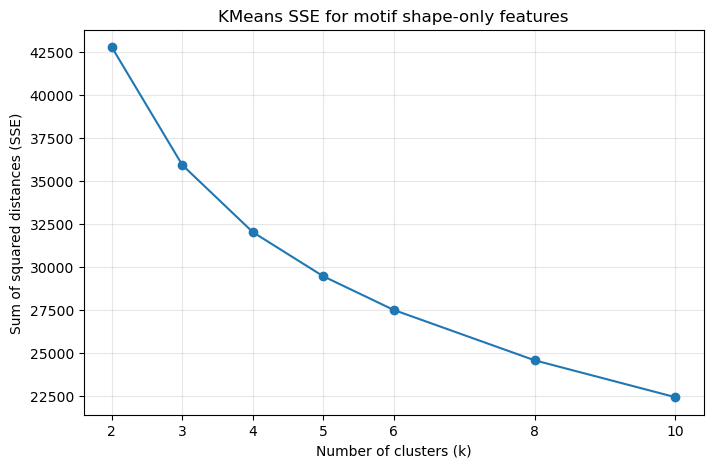

In [54]:
#plot SSE for KMeans on motif shape-only features
sse_shape_only = []
for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=20
    )
    model.fit(X_motif_shape_scaled)
    sse_shape_only.append(model.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse_shape_only, marker='o')
plt.title("KMeans SSE for motif shape-only features")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Sum of squared distances (SSE)")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

In [55]:
# Select the best motif-based KMeans solution with k = 4

selected_k = 4

candidate_k4_df = motif_kmeans_results_df[
    motif_kmeans_results_df["k"] == selected_k
].copy()

display(
    candidate_k4_df
    .sort_values("silhouette", ascending=False)
)

best_motif_k4_row = candidate_k4_df.loc[
    candidate_k4_df["silhouette"].idxmax()
]

display(best_motif_k4_row)

best_motif_k4_result = next(
    row for row in motif_kmeans_results
    if (
        row["representation"] == best_motif_k4_row["representation"]
        and row["k"] == selected_k
    )
)

best_motif_labels = best_motif_k4_result["labels"]
best_motif_model = best_motif_k4_result["model"]
X_best_motif_features = best_motif_k4_result["X_features"]

motif_features_df["cluster_motif_kmeans"] = best_motif_labels

print("Selected motif-based clustering:")
print("Representation:", best_motif_k4_row["representation"])
print("k:", selected_k)
print("Silhouette:", best_motif_k4_row["silhouette"])
print("ARI vs target:", best_motif_k4_row["ARI_vs_target"])
print("NMI vs target:", best_motif_k4_row["NMI_vs_target"])

print("\nCluster sizes:")
display(
    motif_features_df["cluster_motif_kmeans"]
    .value_counts()
    .sort_index()
)

print("\nCluster percentages:")
display(
    (
        motif_features_df["cluster_motif_kmeans"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

,method,representation,k,silhouette,ARI_vs_target,NMI_vs_target,min_cluster_size,max_cluster_size,imbalance_ratio
9,KMeans,motif_shape_plus_summary,4,0.311259,0.000537,0.000381,219,2691,12.287671
2,KMeans,motif_shape_only,4,0.302513,0.000791,0.000128,223,2661,11.932735


method                                KMeans
representation      motif_shape_plus_summary
k                                          4
silhouette                          0.311259
ARI_vs_target                       0.000537
NMI_vs_target                       0.000381
min_cluster_size                         219
max_cluster_size                        2691
imbalance_ratio                    12.287671
Name: 9, dtype: object

Selected motif-based clustering:
Representation: motif_shape_plus_summary
k: 4
Silhouette: 0.31125887595683066
ARI vs target: 0.0005371898304413631
NMI vs target: 0.00038093953659011593

Cluster sizes:


cluster_motif_kmeans
0     628
1    2691
2     219
3     772
Name: count, dtype: int64


Cluster percentages:


cluster_motif_kmeans
0    14.57
1    62.44
2     5.08
3    17.91
Name: proportion, dtype: float64

Target counts by motif cluster:


target,0,1
cluster_motif_kmeans,,
0,427,201
1,1803,888
2,136,83
3,522,250


Target proportions by motif cluster:


target,0,1
cluster_motif_kmeans,,
0,0.679936,0.320064
1,0.670011,0.329989
2,0.621005,0.378995
3,0.676166,0.323834


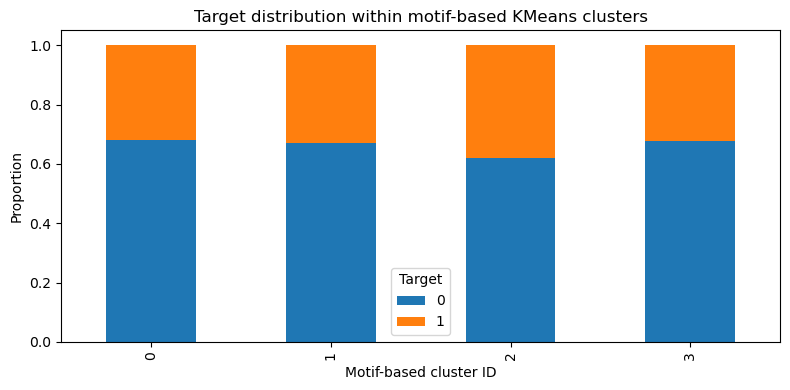

In [56]:
# Target distribution by selected motif-based cluster

motif_cluster_target_counts = pd.crosstab(
    motif_features_df["cluster_motif_kmeans"],
    motif_features_df["target"]
)

motif_cluster_target_props = pd.crosstab(
    motif_features_df["cluster_motif_kmeans"],
    motif_features_df["target"],
    normalize="index"
)

print("Target counts by motif cluster:")
display(motif_cluster_target_counts)

print("Target proportions by motif cluster:")
display(motif_cluster_target_props)

motif_cluster_target_props.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.ylabel("Proportion")
plt.xlabel("Motif-based cluster ID")
plt.title("Target distribution within motif-based KMeans clusters")
plt.legend(title="Target")
plt.tight_layout()
plt.show()


In [57]:
# Select the best motif-based KMeans solution with k = 4

selected_k = 4

candidate_k4_df = motif_kmeans_results_df[
    motif_kmeans_results_df["k"] == selected_k
].copy()

display(
    candidate_k4_df
    .sort_values("silhouette", ascending=False)
)

best_motif_k4_row = candidate_k4_df.loc[
    candidate_k4_df["silhouette"].idxmax()
]

display(best_motif_k4_row)

best_motif_k4_result = next(
    row for row in motif_kmeans_results
    if (
        row["representation"] == best_motif_k4_row["representation"]
        and row["k"] == selected_k
    )
)

best_motif_labels = best_motif_k4_result["labels"]
best_motif_model = best_motif_k4_result["model"]
X_best_motif_features = best_motif_k4_result["X_features"]

motif_features_df["cluster_motif_kmeans"] = best_motif_labels

print("Selected motif-based clustering:")
print("Representation:", best_motif_k4_row["representation"])
print("k:", selected_k)
print("Silhouette:", best_motif_k4_row["silhouette"])
print("ARI vs target:", best_motif_k4_row["ARI_vs_target"])
print("NMI vs target:", best_motif_k4_row["NMI_vs_target"])

print("\nCluster sizes:")
display(
    motif_features_df["cluster_motif_kmeans"]
    .value_counts()
    .sort_index()
)

print("\nCluster percentages:")
display(
    (
        motif_features_df["cluster_motif_kmeans"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

,method,representation,k,silhouette,ARI_vs_target,NMI_vs_target,min_cluster_size,max_cluster_size,imbalance_ratio
9,KMeans,motif_shape_plus_summary,4,0.311259,0.000537,0.000381,219,2691,12.287671
2,KMeans,motif_shape_only,4,0.302513,0.000791,0.000128,223,2661,11.932735


method                                KMeans
representation      motif_shape_plus_summary
k                                          4
silhouette                          0.311259
ARI_vs_target                       0.000537
NMI_vs_target                       0.000381
min_cluster_size                         219
max_cluster_size                        2691
imbalance_ratio                    12.287671
Name: 9, dtype: object

Selected motif-based clustering:
Representation: motif_shape_plus_summary
k: 4
Silhouette: 0.31125887595683066
ARI vs target: 0.0005371898304413631
NMI vs target: 0.00038093953659011593

Cluster sizes:


cluster_motif_kmeans
0     628
1    2691
2     219
3     772
Name: count, dtype: int64


Cluster percentages:


cluster_motif_kmeans
0    14.57
1    62.44
2     5.08
3    17.91
Name: proportion, dtype: float64

Target counts by motif cluster:


target,0,1
cluster_motif_kmeans,,
0,427,201
1,1803,888
2,136,83
3,522,250


Target proportions by motif cluster:


target,0,1
cluster_motif_kmeans,,
0,0.679936,0.320064
1,0.670011,0.329989
2,0.621005,0.378995
3,0.676166,0.323834


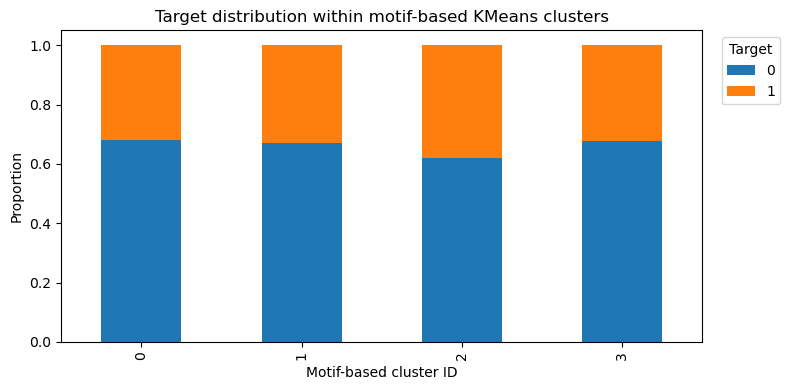

In [58]:
# Target distribution by selected motif-based cluster

motif_cluster_target_counts = pd.crosstab(
    motif_features_df["cluster_motif_kmeans"],
    motif_features_df["target"]
)

motif_cluster_target_props = pd.crosstab(
    motif_features_df["cluster_motif_kmeans"],
    motif_features_df["target"],
    normalize="index"
)

print("Target counts by motif cluster:")
display(motif_cluster_target_counts)

print("Target proportions by motif cluster:")
display(motif_cluster_target_props)

ax = motif_cluster_target_props.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.ylabel("Proportion")
plt.xlabel("Motif-based cluster ID")
plt.title("Target distribution within motif-based KMeans clusters")
plt.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


PCA explained variance ratio: [0.35892232 0.17382215]
Total explained variance: 0.5327444773142225


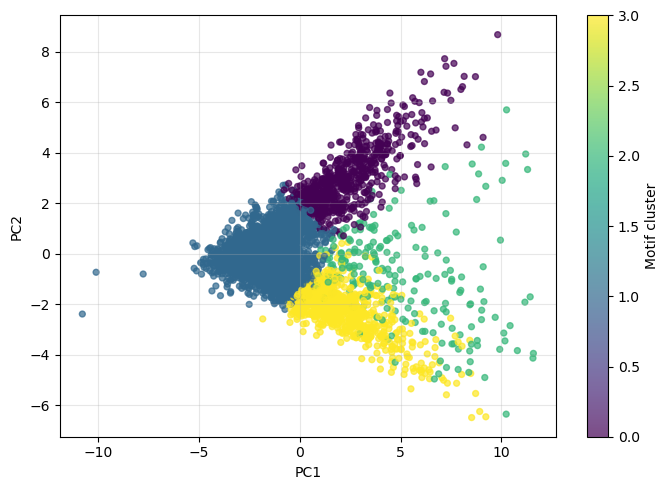

In [69]:
# PCA visualization of selected motif-based clusters

from sklearn.decomposition import PCA

labels_motif = motif_features_df["cluster_motif_kmeans"].to_numpy()

pca_motif = PCA(
    n_components=2,
    random_state=random_state
)

X_motif_pca = pca_motif.fit_transform(X_best_motif_features)

print("PCA explained variance ratio:", pca_motif.explained_variance_ratio_)
print("Total explained variance:", pca_motif.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_motif_pca[:, 0],
    X_motif_pca[:, 1],
    c=labels_motif,
    alpha=0.70,
    s=18
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Motif cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

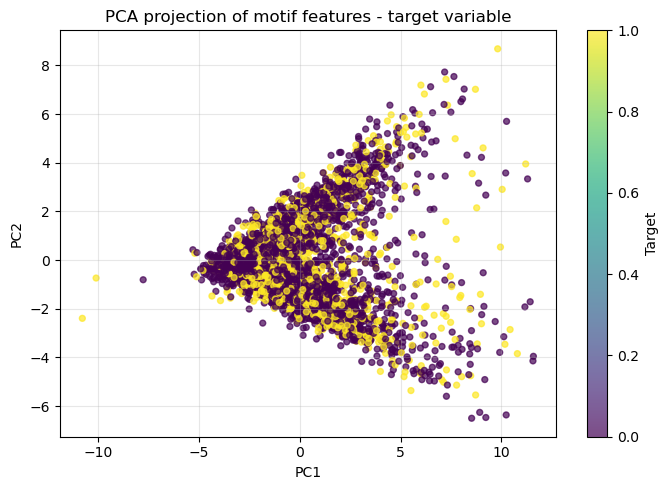

In [60]:
# PCA projection colored by target variable

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_motif_pca[:, 0],
    X_motif_pca[:, 1],
    c=motif_features_df["target"],
    alpha=0.70,
    s=18
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of motif features - target variable")
plt.colorbar(scatter, label="Target")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


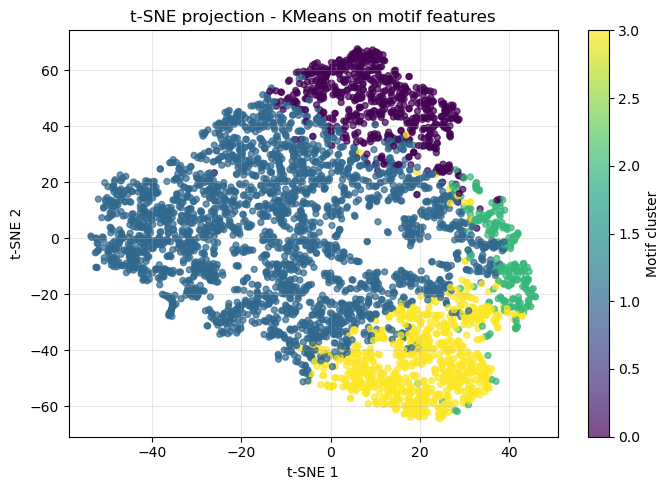

In [61]:
# t-SNE visualization of selected motif-based clusters

from sklearn.manifold import TSNE

tsne_motif = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=random_state
)

X_motif_tsne = tsne_motif.fit_transform(X_best_motif_features)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_motif_tsne[:, 0],
    X_motif_tsne[:, 1],
    c=labels_motif,
    alpha=0.70,
    s=18
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection - KMeans on motif features")
plt.colorbar(scatter, label="Motif cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

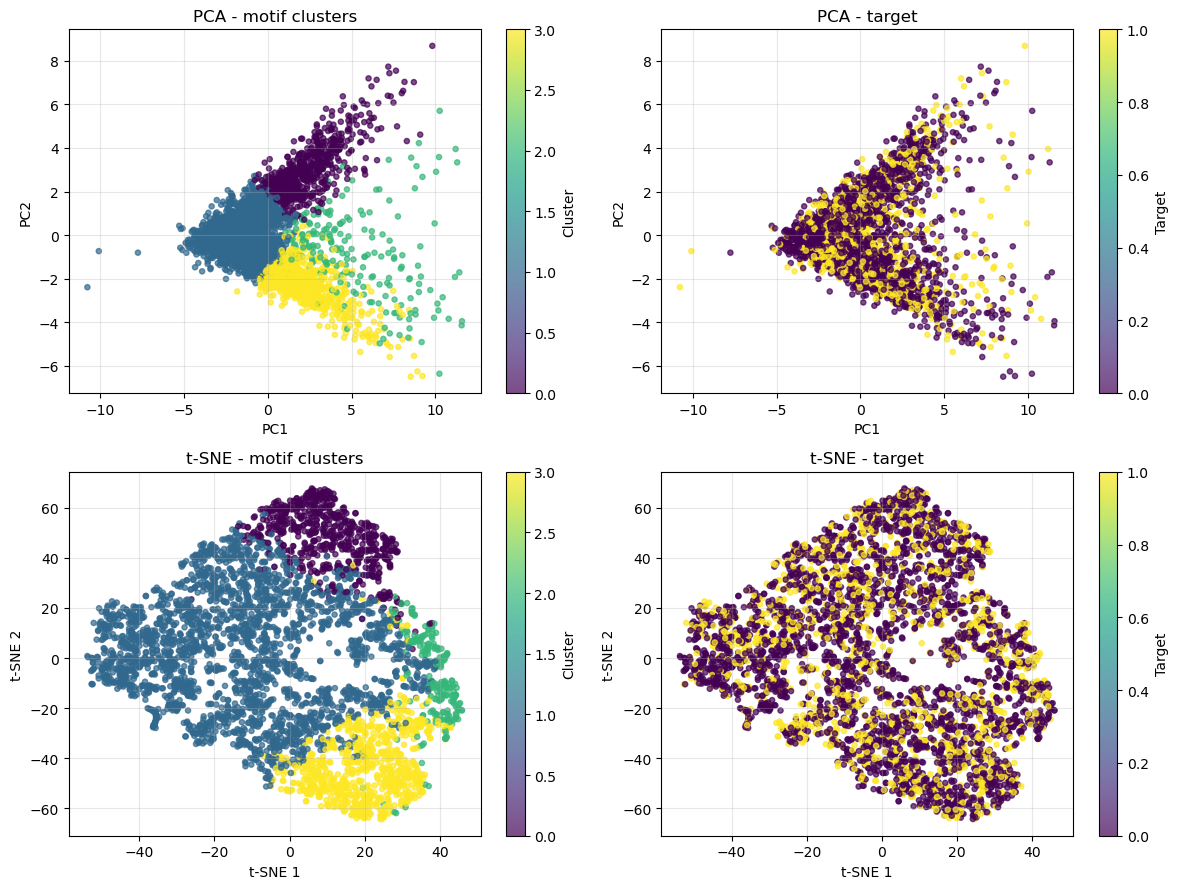

In [62]:
# Compact visualization: PCA and t-SNE, colored by motif cluster and target

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# PCA - clusters
sc1 = axes[0, 0].scatter(
    X_motif_pca[:, 0],
    X_motif_pca[:, 1],
    c=labels_motif,
    alpha=0.70,
    s=14
)
axes[0, 0].set_title("PCA - motif clusters")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")
axes[0, 0].grid(alpha=0.3)
fig.colorbar(sc1, ax=axes[0, 0], label="Cluster")

# PCA - target
sc2 = axes[0, 1].scatter(
    X_motif_pca[:, 0],
    X_motif_pca[:, 1],
    c=motif_features_df["target"],
    alpha=0.70,
    s=14
)
axes[0, 1].set_title("PCA - target")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")
axes[0, 1].grid(alpha=0.3)
fig.colorbar(sc2, ax=axes[0, 1], label="Target")

# t-SNE - clusters
sc3 = axes[1, 0].scatter(
    X_motif_tsne[:, 0],
    X_motif_tsne[:, 1],
    c=labels_motif,
    alpha=0.70,
    s=14
)
axes[1, 0].set_title("t-SNE - motif clusters")
axes[1, 0].set_xlabel("t-SNE 1")
axes[1, 0].set_ylabel("t-SNE 2")
axes[1, 0].grid(alpha=0.3)
fig.colorbar(sc3, ax=axes[1, 0], label="Cluster")

# t-SNE - target
sc4 = axes[1, 1].scatter(
    X_motif_tsne[:, 0],
    X_motif_tsne[:, 1],
    c=motif_features_df["target"],
    alpha=0.70,
    s=14
)
axes[1, 1].set_title("t-SNE - target")
axes[1, 1].set_xlabel("t-SNE 1")
axes[1, 1].set_ylabel("t-SNE 2")
axes[1, 1].grid(alpha=0.3)
fig.colorbar(sc4, ax=axes[1, 1], label="Target")

plt.tight_layout()
plt.show()

PCA explained variance ratio: [0.35892232 0.17382215]
Total explained variance: 0.5327444773142225


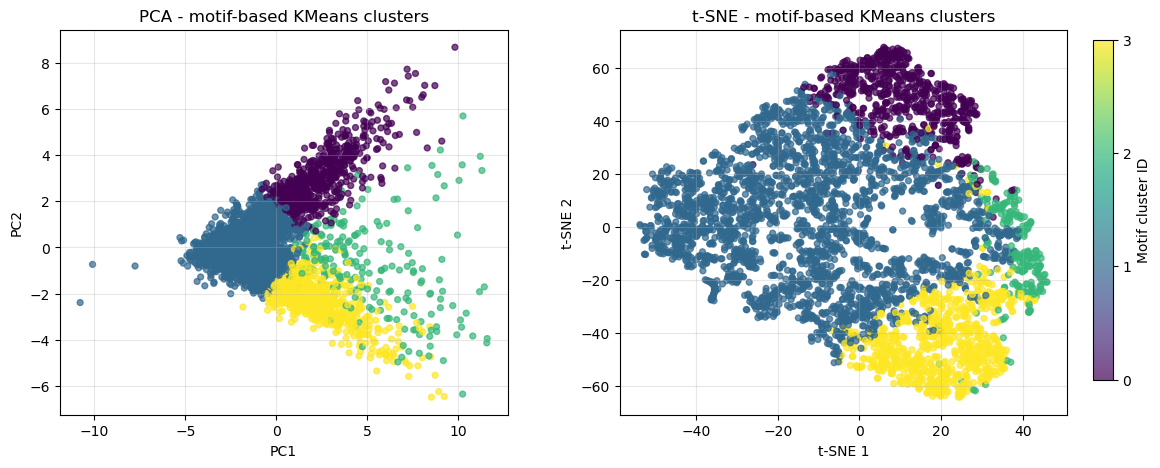

In [68]:
# PCA and t-SNE side-by-side visualization of motif-based clusters

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

labels_motif = motif_features_df["cluster_motif_kmeans"].to_numpy()

# PCA
pca_motif = PCA(
    n_components=2,
    random_state=random_state
)

X_motif_pca = pca_motif.fit_transform(X_best_motif_features)

print("PCA explained variance ratio:", pca_motif.explained_variance_ratio_)
print("Total explained variance:", pca_motif.explained_variance_ratio_.sum())

# t-SNE
tsne_motif = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=random_state
)

X_motif_tsne = tsne_motif.fit_transform(X_best_motif_features)

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=False)

# PCA plot
sc1 = axes[0].scatter(
    X_motif_pca[:, 0],
    X_motif_pca[:, 1],
    c=labels_motif,
    alpha=0.70,
    s=18,
    cmap="viridis"
)

axes[0].set_title("PCA - motif-based KMeans clusters")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.3)

# t-SNE plot
sc2 = axes[1].scatter(
    X_motif_tsne[:, 0],
    X_motif_tsne[:, 1],
    c=labels_motif,
    alpha=0.70,
    s=18,
    cmap="viridis"
)

axes[1].set_title("t-SNE - motif-based KMeans clusters")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.3)

# Shared colorbar
fig.subplots_adjust(right=0.90, wspace=0.25)

cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.68])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Motif cluster ID")
cbar.set_ticks(np.sort(np.unique(labels_motif)))

plt.show()

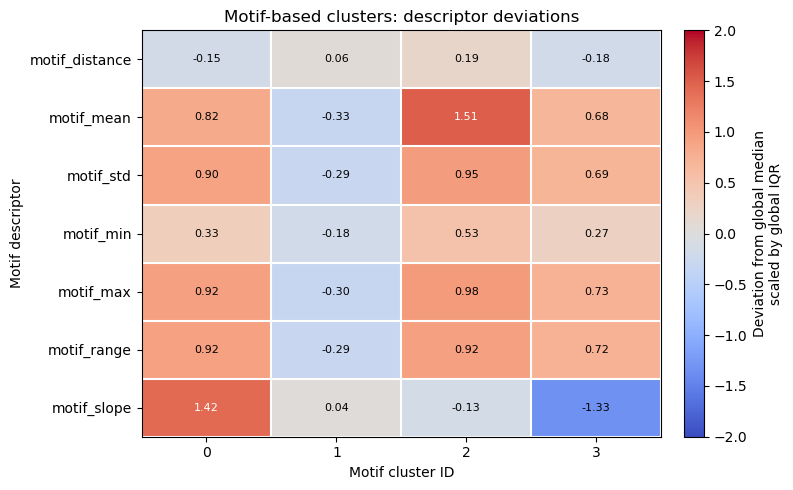

In [63]:
# Characterize motif clusters using motif summary descriptors

cluster_col = "cluster_motif_kmeans"

cluster_medians = motif_features_df.groupby(cluster_col)[motif_summary_cols].median()
global_median = motif_features_df[motif_summary_cols].median()

q75 = motif_features_df[motif_summary_cols].quantile(0.75)
q25 = motif_features_df[motif_summary_cols].quantile(0.25)
global_iqr = q75 - q25

eps = 1e-8

motif_cluster_deviation = (
    cluster_medians - global_median
) / (global_iqr.replace(0, np.nan) + eps)

heatmap_matrix = motif_cluster_deviation.T.clip(-2, 2)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    heatmap_matrix,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2
)

ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
ax.set_xticklabels(heatmap_matrix.columns.astype(str), fontsize=10)

ax.set_yticks(np.arange(heatmap_matrix.shape[0]))
ax.set_yticklabels(heatmap_matrix.index, fontsize=10)

ax.set_xlabel("Motif cluster ID")
ax.set_ylabel("Motif descriptor")
ax.set_title("Motif-based clusters: descriptor deviations")

ax.set_xticks(np.arange(-0.5, heatmap_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heatmap_matrix.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(heatmap_matrix.shape[0]):
    for j in range(heatmap_matrix.shape[1]):
        value = heatmap_matrix.iloc[i, j]
        text_color = "white" if abs(value) > 1.4 else "black"
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Deviation from global median\nscaled by global IQR")

plt.tight_layout()
plt.show()

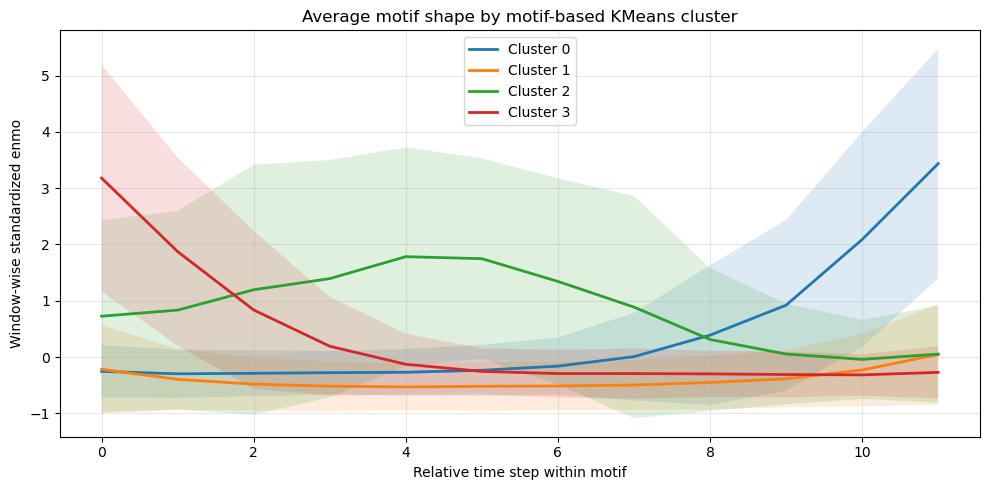

In [64]:
# Plot average motif shape per cluster

motif_shape_cols = [f"motif_t{i}" for i in range(motif_m)]

motif_shape_with_cluster_df = X_motif_shape_df.copy()
motif_shape_with_cluster_df["cluster_motif_kmeans"] = motif_features_df["cluster_motif_kmeans"].to_numpy()

cluster_mean_motifs = (
    motif_shape_with_cluster_df
    .groupby("cluster_motif_kmeans")[motif_shape_cols]
    .mean()
)

cluster_std_motifs = (
    motif_shape_with_cluster_df
    .groupby("cluster_motif_kmeans")[motif_shape_cols]
    .std()
)

time_axis = np.arange(motif_m)

plt.figure(figsize=(10, 5))

for cluster_id in cluster_mean_motifs.index:
    mean_values = cluster_mean_motifs.loc[cluster_id].to_numpy()
    std_values = cluster_std_motifs.loc[cluster_id].to_numpy()

    plt.plot(
        time_axis,
        mean_values,
        linewidth=2,
        label=f"Cluster {cluster_id}"
    )

    plt.fill_between(
        time_axis,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.15
    )

plt.xlabel("Relative time step within motif")
plt.ylabel(f"Window-wise standardized {motif_signal}")
plt.title("Average motif shape by motif-based KMeans cluster")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

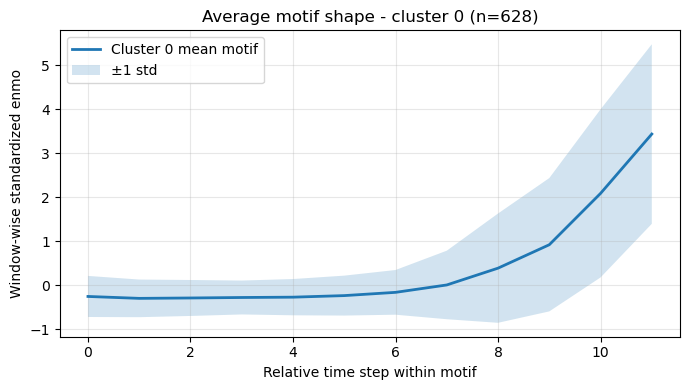

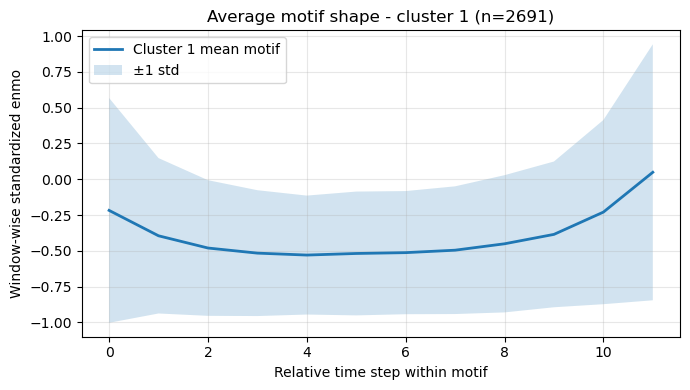

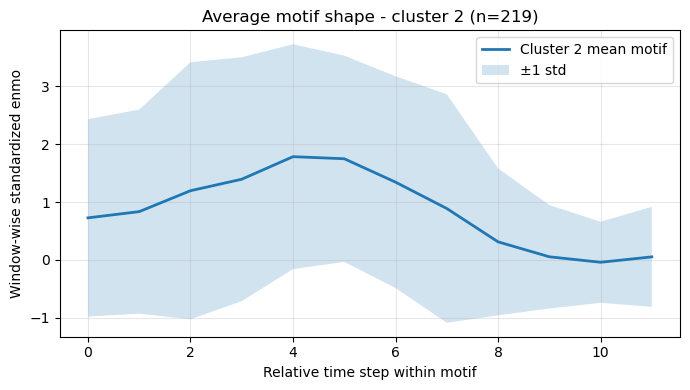

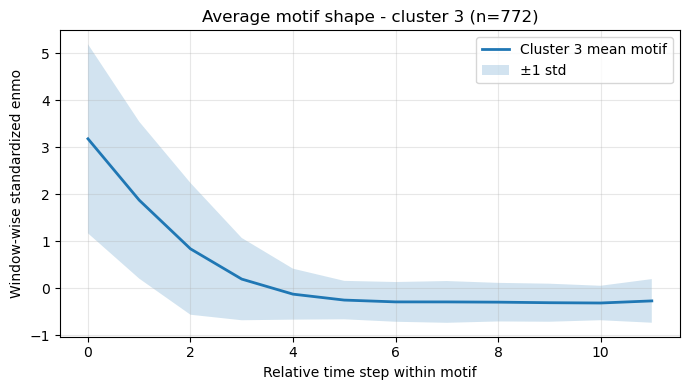

In [65]:
# Plot average motif shape per cluster separately

for cluster_id in cluster_mean_motifs.index:
    mean_values = cluster_mean_motifs.loc[cluster_id].to_numpy()
    std_values = cluster_std_motifs.loc[cluster_id].to_numpy()

    cluster_size = (
        motif_features_df["cluster_motif_kmeans"]
        .value_counts()
        .sort_index()
        .loc[cluster_id]
    )

    plt.figure(figsize=(7, 4))

    plt.plot(
        time_axis,
        mean_values,
        linewidth=2,
        label=f"Cluster {cluster_id} mean motif"
    )

    plt.fill_between(
        time_axis,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.20,
        label="±1 std"
    )

    plt.xlabel("Relative time step within motif")
    plt.ylabel(f"Window-wise standardized {motif_signal}")
    plt.title(f"Average motif shape - cluster {cluster_id} (n={cluster_size})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [66]:
# Find representative motif per cluster

representative_motif_rows = []

for cluster_id in sorted(motif_features_df["cluster_motif_kmeans"].unique()):
    cluster_indices = np.where(
        motif_features_df["cluster_motif_kmeans"].to_numpy() == cluster_id
    )[0]

    X_cluster = X_motif_shape[cluster_indices]
    cluster_center = X_cluster.mean(axis=0)

    distances = np.linalg.norm(X_cluster - cluster_center, axis=1)

    representative_local_idx = np.argmin(distances)
    representative_global_idx = cluster_indices[representative_local_idx]

    row = motif_features_df.iloc[representative_global_idx]

    representative_motif_rows.append({
        "cluster_id": cluster_id,
        "representative_row_index": representative_global_idx,
        "series_index": row["series_index"],
        "subject_id": row["subject_id"],
        "target": row["target"],
        "motif_start": row["motif_start"],
        "motif_nearest_neighbor": row["motif_nearest_neighbor"],
        "motif_distance": row["motif_distance"],
        "motif_mean": row["motif_mean"],
        "motif_std": row["motif_std"],
        "motif_range": row["motif_range"],
        "motif_slope": row["motif_slope"]
    })

representative_motifs_df = pd.DataFrame(representative_motif_rows)

display(representative_motifs_df)

,cluster_id,representative_row_index,series_index,subject_id,target,motif_start,motif_nearest_neighbor,motif_distance,motif_mean,motif_std,motif_range,motif_slope
0,0,213,213,1110,1,16,91,0.890922,0.231867,1.195075,3.766493,3.384106
1,1,1952,1952,2338,0,131,150,1.106033,-0.413340,0.143892,0.579665,0.423894
2,2,2999,2999,3558,0,91,162,0.967341,0.660372,1.020782,3.054494,-0.207850
3,3,2129,2129,129,0,107,116,0.680497,0.234773,1.121955,3.987734,-3.801633


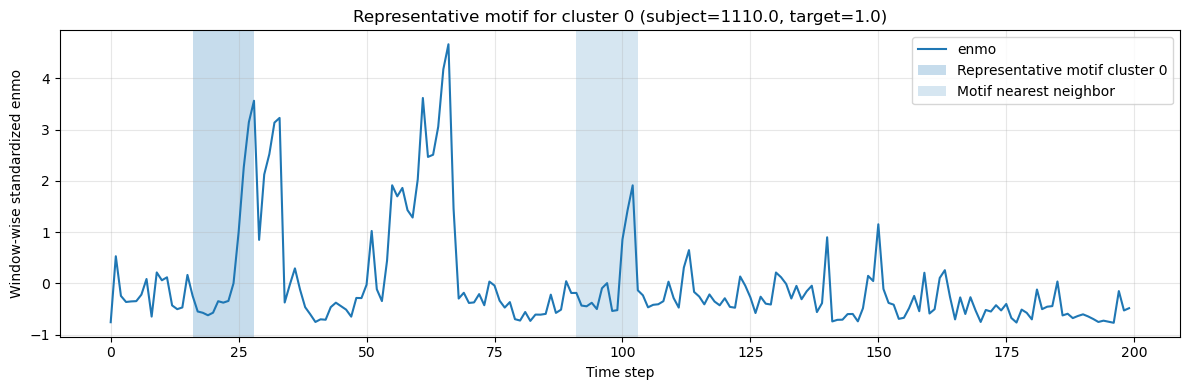

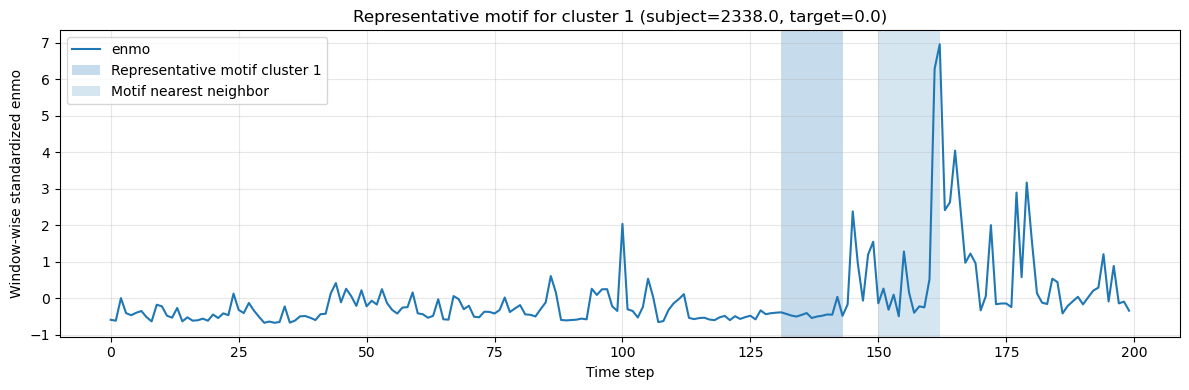

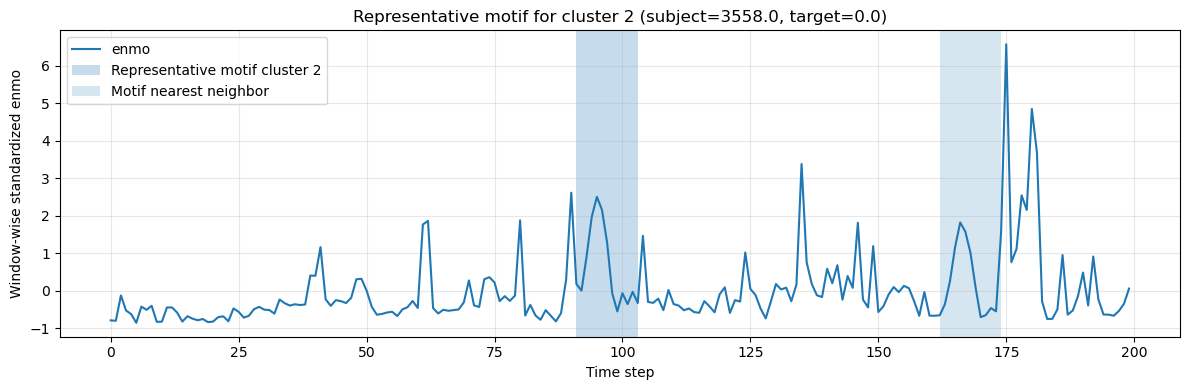

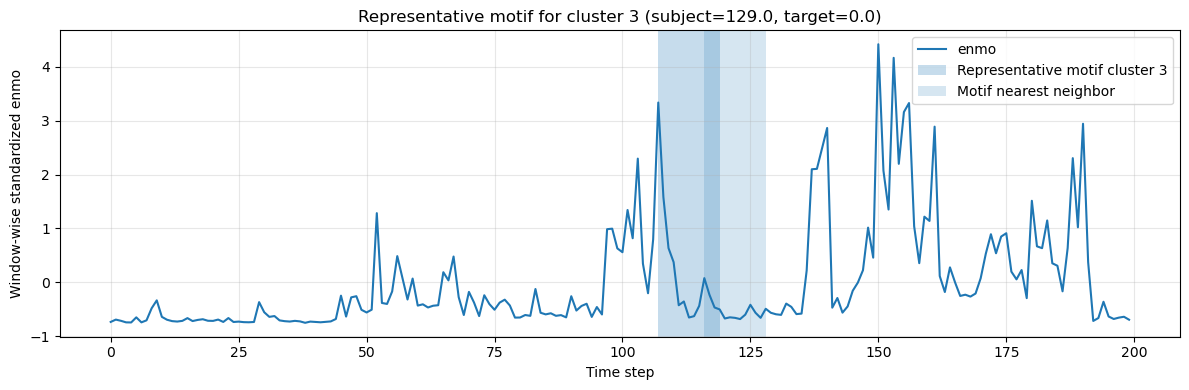

In [67]:
# Plot representative motif highlighted on its original time-series window

for _, row in representative_motifs_df.iterrows():
    cluster_id = int(row["cluster_id"])
    series_index = int(row["series_index"])
    motif_start = int(row["motif_start"])
    motif_nn = int(row["motif_nearest_neighbor"])

    ts_df = CMI_timeseries_subject_scaled[series_index]
    x = ts_df[motif_signal].to_numpy().astype(float)

    plt.figure(figsize=(12, 4))

    plt.plot(
        x,
        linewidth=1.5,
        label=motif_signal
    )

    plt.axvspan(
        motif_start,
        motif_start + motif_m,
        alpha=0.25,
        label=f"Representative motif cluster {cluster_id}"
    )

    plt.axvspan(
        motif_nn,
        motif_nn + motif_m,
        alpha=0.18,
        label="Motif nearest neighbor"
    )

    plt.title(
        f"Representative motif for cluster {cluster_id} "
        f"(subject={row['subject_id']}, target={row['target']})"
    )

    plt.xlabel("Time step")
    plt.ylabel(f"Window-wise standardized {motif_signal}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()